In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load and clean data
df_dementia_caregiving = pd.read_csv("/content/Oura sharing data_06092025 (2).csv")

In [ ]:
print(df_dementia_caregiving.head())

    ID            Consent_date  Oura day  HRV  Reflected the previous day HRV  \
0  101                     NaN         0  999                              25   
1  101  10/01/2024; 11/14/2024         1   25                              20   
2  101                     NaN         2   20                              22   
3  101                     NaN         3   22                              21   
4  101                     NaN         4   21                              19   

   Caregiving from the previous day  Daily caregiving yes or no  \
0                                 2                           1   
1                                 1                           1   
2                                 2                           1   
3                                 2                           1   
4                                 0                           0   

   Total dementia caregiving hours/day  \
0                                  0.0   
1                         

=== Simple Linear Regression: Within-Person Effect (|Z_HRV|, MinMax Scaled) ===
Coefficient: 0.0224
Intercept: 0.4749
R² Score: 0.0015
MAE: 0.1571


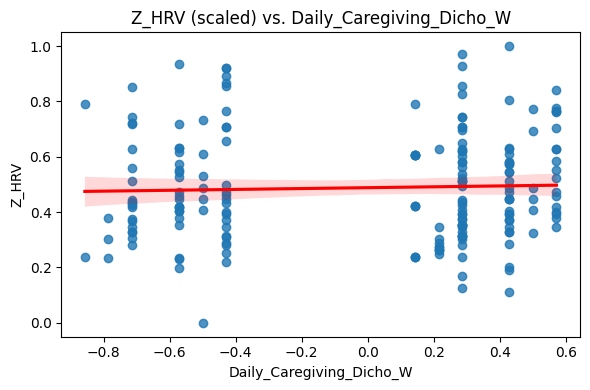


=== Simple Linear Regression: Between-Person Effect (|Z_HRV|, MinMax Scaled) ===
Coefficient: -0.0992
Intercept:  0.5320
R² Score:    0.0262
MAE:         0.1562


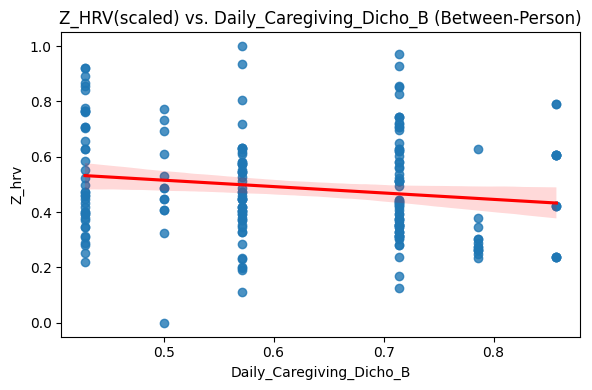

In [6]:


# Convert necessary columns
df_dementia_caregiving['Z_HRV'] = pd.to_numeric(df_dementia_caregiving['Z_HRV'], errors='coerce')
df_dementia_caregiving['Daily_Caregiving_Dicho_W'] = pd.to_numeric(df_dementia_caregiving['Daily_Caregiving_Dicho_W'], errors='coerce')
df_dementia_caregiving['Daily_Caregiving_Dicho_B'] = pd.to_numeric(df_dementia_caregiving['Daily_Caregiving_Dicho_B'], errors='coerce')

# ---------------------------
# MODEL 1: Within-person (Absolute HRV)
# ---------------------------
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import seaborn as sns
import matplotlib.pyplot as plt

# Filter and clean data
df_within = df_dementia_caregiving[['Z_HRV', 'Daily_Caregiving_Dicho_W']].dropna()

# Take absolute value of Z_HRV
#df_within['Z_HRV'] = df_within['Z_HRV'].abs()

# Define features and target
X_within_raw = df_within[['Daily_Caregiving_Dicho_W']]
y_within_raw = df_within[['Z_HRV']]

# Apply MinMax Scaling
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_within = scaler_X.fit_transform(X_within_raw)
y_within = scaler_y.fit_transform(y_within_raw).ravel()

# Fit model
model_within = LinearRegression().fit(X_within, y_within)
y_pred_within = model_within.predict(X_within)

# Output results
print("=== Simple Linear Regression: Within-Person Effect (|Z_HRV|, MinMax Scaled) ===")
print(f"Coefficient: {model_within.coef_[0]:.4f}")
print(f"Intercept: {model_within.intercept_:.4f}")
print(f"R² Score: {r2_score(y_within, y_pred_within):.4f}")
print(f"MAE: {mean_absolute_error(y_within, y_pred_within):.4f}")

# Plot (use original unscaled X for labeling clarity)
plt.figure(figsize=(6, 4))
sns.regplot(x=X_within_raw['Daily_Caregiving_Dicho_W'], y=y_within, line_kws={"color": "red"})
plt.title("Z_HRV (scaled) vs. Daily_Caregiving_Dicho_W")
plt.xlabel("Daily_Caregiving_Dicho_W")
plt.ylabel("Z_HRV")
plt.tight_layout()
plt.show()


# ---------------------------
# MODEL 2: Between-person
# ---------------------------
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# MODEL 2: Between-person (|Z_HRV|, MinMax scaled)
# ---------------------------

# 1) Filter relevant columns and drop rows with missing values
df_between = df_dementia_caregiving[['Z_HRV', 'Daily_Caregiving_Dicho_B']].dropna().copy()

# 2) Take absolute value of Z_HRV
#df_between['Z_HRV'] = df_between['Z_HRV'].abs()

# 3) Separate raw feature & target
X_between_raw = df_between[['Daily_Caregiving_Dicho_B']]
y_between_raw = df_between[['Z_HRV']]

# 4) Min-Max scaling
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_between = scaler_X.fit_transform(X_between_raw)
y_between = scaler_y.fit_transform(y_between_raw).ravel()

# 5) Fit linear regression
model_between = LinearRegression().fit(X_between, y_between)
y_pred_between = model_between.predict(X_between)

# 6) Report results
print("\n=== Simple Linear Regression: Between-Person Effect (|Z_HRV|, MinMax Scaled) ===")
print(f"Coefficient: {model_between.coef_[0]:.4f}")
print(f"Intercept:  {model_between.intercept_:.4f}")
print(f"R² Score:    {r2_score(y_between, y_pred_between):.4f}")
print(f"MAE:         {mean_absolute_error(y_between, y_pred_between):.4f}")

# 7) Plot (raw X for readability, scaled Y)
plt.figure(figsize=(6, 4))
sns.regplot(x=X_between_raw['Daily_Caregiving_Dicho_B'], y=y_between,
            line_kws={"color": "red"})
plt.title("Z_HRV(scaled) vs. Daily_Caregiving_Dicho_B (Between-Person)")
plt.xlabel("Daily_Caregiving_Dicho_B")
plt.ylabel("Z_hrv")
plt.tight_layout()
plt.show()



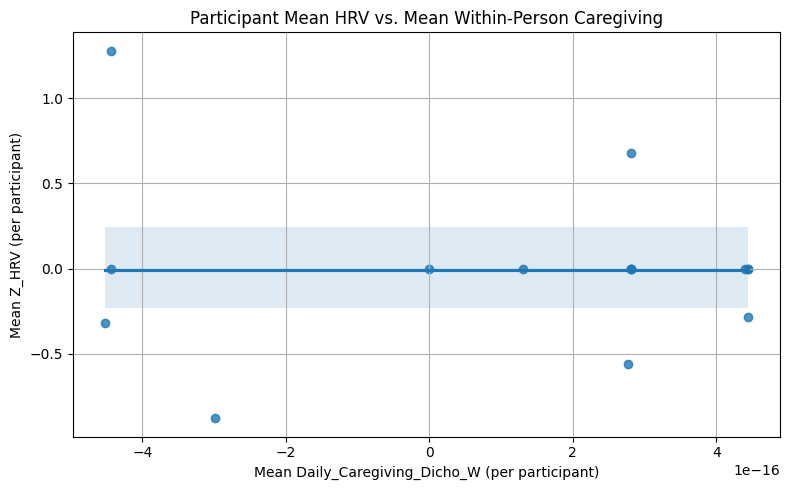

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



df_dementia_caregiving['ID'] = df_dementia_caregiving['ID'].astype(str)

# Drop missing
df_avg = df_dementia_caregiving[['ID', 'Z_HRV', 'Daily_Caregiving_Dicho_W']]

#f_avg['Z_HRV'] = df_avg['Z_HRV'].abs()


# Compute participant-level means
df_summary = df_avg.groupby('ID').agg({
    'Z_HRV': 'mean',
    'Daily_Caregiving_Dicho_W': 'mean'
}).reset_index()

# Rename for clarity
df_summary.rename(columns={
    'Z_HRV': 'Mean_Z_HRV',
    'Daily_Caregiving_Dicho_W': 'Mean_Caregiving_Within'
}, inplace=True)

# Plot regression
plt.figure(figsize=(8, 5))
sns.regplot(data=df_summary, x='Mean_Caregiving_Within', y='Mean_Z_HRV')
plt.title("Participant Mean HRV vs. Mean Within-Person Caregiving")
plt.xlabel("Mean Daily_Caregiving_Dicho_W (per participant)")
plt.ylabel("Mean Z_HRV (per participant)")
plt.grid(True)
plt.tight_layout()
plt.show()


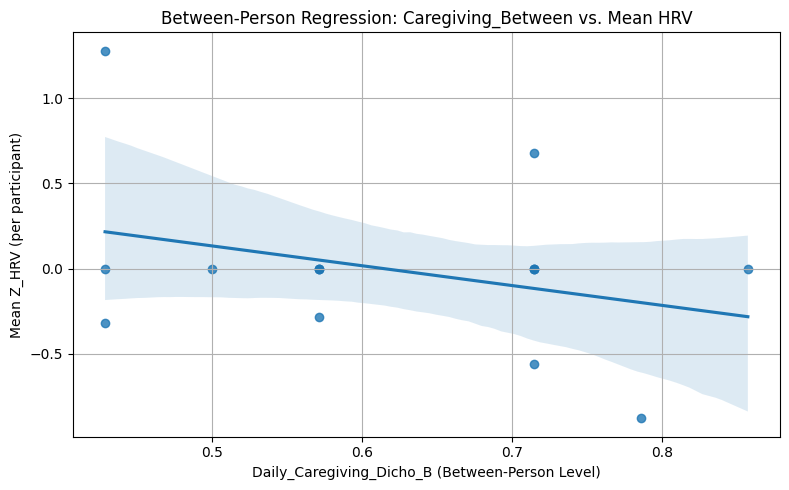

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load and clean data




# Drop missing
df_bp = df_dementia_caregiving[['ID', 'Z_HRV', 'Daily_Caregiving_Dicho_B']]

#df_bp['Z_HRV'] = df_bp['Z_HRV'].abs()

# Compute participant-level mean HRV and between-person caregiving
df_bp_summary = df_bp.groupby('ID').agg({
    'Z_HRV': 'mean',
    'Daily_Caregiving_Dicho_B': 'first'  # between-person value is constant per participant
}).reset_index()

# Rename for clarity
df_bp_summary.rename(columns={
    'Z_HRV': 'Mean_Z_HRV',
    'Daily_Caregiving_Dicho_B': 'Caregiving_Between'
}, inplace=True)

# Plot regression
plt.figure(figsize=(8, 5))
sns.regplot(data=df_bp_summary, x='Caregiving_Between', y='Mean_Z_HRV')
plt.title("Between-Person Regression: Caregiving_Between vs. Mean HRV")
plt.xlabel("Daily_Caregiving_Dicho_B (Between-Person Level)")
plt.ylabel("Mean Z_HRV (per participant)")
plt.grid(True)
plt.tight_layout()
plt.show()


                            OLS Regression Results                            
Dep. Variable:                  Z_HRV   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.3366
Date:                Sat, 25 Oct 2025   Prob (F-statistic):              0.562
Time:                        19:42:01   Log-Likelihood:                -272.44
No. Observations:                 198   AIC:                             548.9
Df Residuals:                     196   BIC:                             555.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0424      0.100      0.

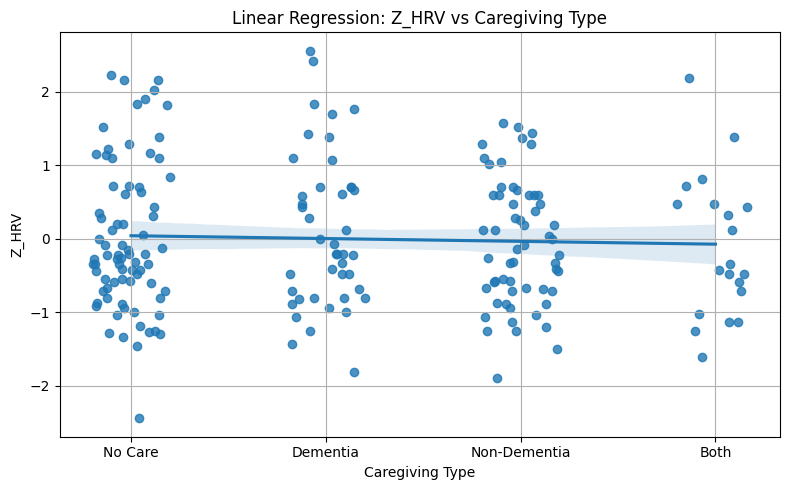

In [9]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Preprocessing
df_dementia_caregiving['Z_HRV'] = pd.to_numeric(df_dementia_caregiving['Z_HRV'], errors='coerce')
df_dementia_caregiving['DxCare'] = pd.to_numeric(df_dementia_caregiving['DxCare'], errors='coerce')
df_dementia_caregiving['NDxCare'] = pd.to_numeric(df_dementia_caregiving['NDxCare'], errors='coerce')
df_dementia_caregiving['BothCare'] = pd.to_numeric(df_dementia_caregiving['BothCare'], errors='coerce')
df_dementia_caregiving['NoCare'] = pd.to_numeric(df_dementia_caregiving['NoCare'], errors='coerce')

# Assign caregiving type
def caregiving_type(row):
    if row['BothCare'] == 1:
        return 'Both Care'
    elif row['DxCare'] == 1:
        return 'Dementia Care'
    elif row['NDxCare'] == 1:
        return 'Non-Dementia Care'
    elif row['NoCare'] == 1:
        return 'No Care'
    else:
        return 'Unknown'

df_dementia_caregiving['Care_Type'] = df_dementia_caregiving.apply(caregiving_type, axis=1)

# Drop missing
df_clean = df_dementia_caregiving[['Care_Type', 'Z_HRV']].dropna()

# Map to numeric
care_type_map = {
    'No Care': 0,
    'Dementia Care': 1,
    'Non-Dementia Care': 2,
    'Both Care': 3
}
df_clean['Care_Type_Code'] = df_clean['Care_Type'].map(care_type_map)

# Step 2: Linear Regression Model
X = sm.add_constant(df_clean['Care_Type_Code'])  # Add intercept
y = df_clean['Z_HRV']

model = sm.OLS(y, X)
results = model.fit()

# Print summary
print(results.summary())

# Step 3: Regression Plot
plt.figure(figsize=(8, 5))
sns.regplot(x='Care_Type_Code', y='Z_HRV', data=df_clean, x_jitter=0.2)
plt.xticks(ticks=[0, 1, 2, 3], labels=['No Care', 'Dementia', 'Non-Dementia', 'Both'])
plt.xlabel("Caregiving Type")
plt.ylabel("Z_HRV")
plt.title("Linear Regression: Z_HRV vs Caregiving Type")
plt.grid(True)
plt.tight_layout()
plt.show()


      ID     Z_HRV  Care_Binary Care_Type
0    101  1.104485            0    DxCare
1    101 -0.676942            1    DxCare
2    101  0.035629            0    DxCare
3    101 -0.320657            0    DxCare
4    101 -1.033228            0    DxCare
..   ...       ...          ...       ...
218  117 -1.132523            1  BothCare
220  117 -0.539924            0  BothCare
221  117 -0.934990            0  BothCare
222  117 -0.934990            0  BothCare
223  117 -1.198367            0  BothCare

[594 rows x 4 columns]


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "

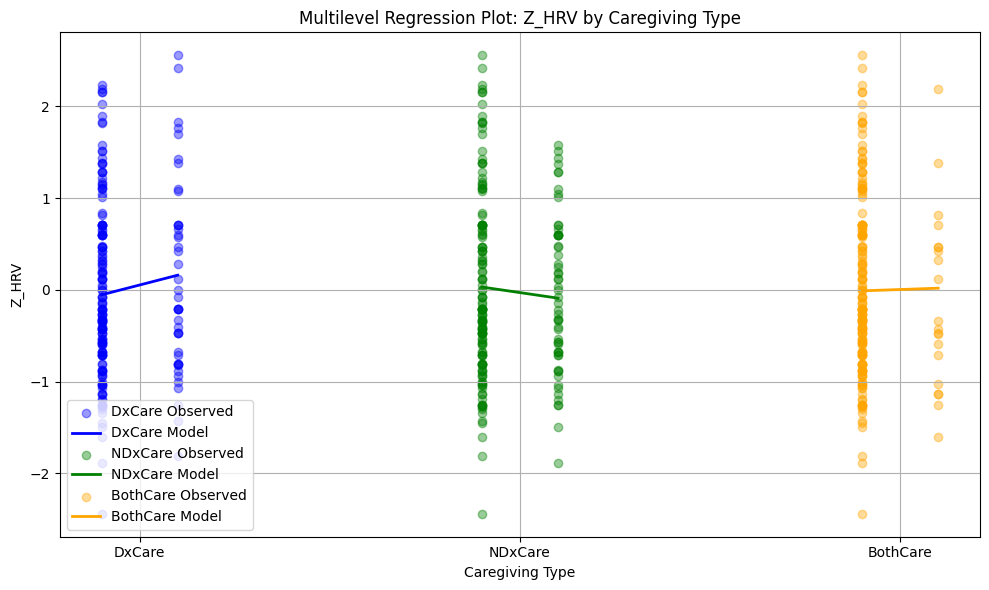

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import numpy as np


df_dementia_caregiving['Z_HRV'] = pd.to_numeric(df_dementia_caregiving['Z_HRV'], errors='coerce')
df_dementia_caregiving['DxCare'] = pd.to_numeric(df_dementia_caregiving['DxCare'], errors='coerce')
df_dementia_caregiving['NDxCare'] = pd.to_numeric(df_dementia_caregiving['NDxCare'], errors='coerce')
df_dementia_caregiving['BothCare'] = pd.to_numeric(df_dementia_caregiving['BothCare'], errors='coerce')
df_dementia_caregiving['ID'] = df_dementia_caregiving['ID'].astype(str)

# Step 2: Filter for positive HRV values and reshape to long format
dfs = []
for col in ['DxCare', 'NDxCare', 'BothCare']:
    temp = df_dementia_caregiving[['ID', 'Z_HRV', col]].copy()
    temp = temp.rename(columns={col: 'Care_Binary'})
    temp['Care_Type'] = col
    dfs.append(temp)

df_long = pd.concat(dfs).dropna()

print(df_long)


# Step 3: Fit multilevel model with random slopes and intercepts
model = smf.mixedlm("Z_HRV ~ Care_Binary * Care_Type", data=df_long, groups="ID", re_formula="~Care_Binary")
result = model.fit()

# Step 4: Plot with separated x-axis positions per caregiving type
plt.figure(figsize=(10, 6))
x_pos = {'DxCare': 1, 'NDxCare': 2, 'BothCare': 3}
colors = {'DxCare': 'blue', 'NDxCare': 'green', 'BothCare': 'orange'}

for care_type in ['DxCare', 'NDxCare', 'BothCare']:
    subset = df_long[df_long['Care_Type'] == care_type]
    x = x_pos[care_type]

    # Extract model coefficients
    intercept = result.params['Intercept']
    slope = result.params['Care_Binary']

    if f'Care_Type[T.{care_type}]' in result.params:
        intercept += result.params[f'Care_Type[T.{care_type}]']
    if f'Care_Binary:Care_Type[T.{care_type}]' in result.params:
        slope += result.params[f'Care_Binary:Care_Type[T.{care_type}]']

    # Scatter plot of observed Z HRV values (jittered)
    jittered_x = [x - 0.1 if care == 0 else x + 0.1 for care in subset['Care_Binary']]
    plt.scatter(jittered_x, subset['Z_HRV'], alpha=0.4, color=colors[care_type], label=f"{care_type} Observed")

    # Regression line
    x_vals = [x - 0.1, x + 0.1]
    y_vals = [intercept + slope * 0, intercept + slope * 1]
    plt.plot(x_vals, y_vals, color=colors[care_type], linewidth=2, label=f"{care_type} Model")

# Step 5: Format plot
plt.xticks([1, 2, 3], ['DxCare', 'NDxCare', 'BothCare'])
plt.xlabel("Caregiving Type")
plt.ylabel("Z_HRV")
plt.title("Multilevel Regression Plot: Z_HRV by Caregiving Type")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


                   Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        Z_HRV    
No. Observations:        198            Method:                    REML     
No. Groups:              15             Scale:                     0.7431   
Min. group size:         10             Log-Likelihood:            -264.4525
Max. group size:         14             Converged:                 Yes      
Mean group size:         13.2                                               
----------------------------------------------------------------------------
                                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------
Intercept                          0.006    0.237  0.027 0.978 -0.458  0.471
C(Care_Type)[T.Dementia Care]      0.160    0.253  0.632 0.527 -0.336  0.656
C(Care_Type)[T.No Care]           -0.044    0.230 -0.191 0.849 -0.494  0.407
C(Care_Type)[T.Non-

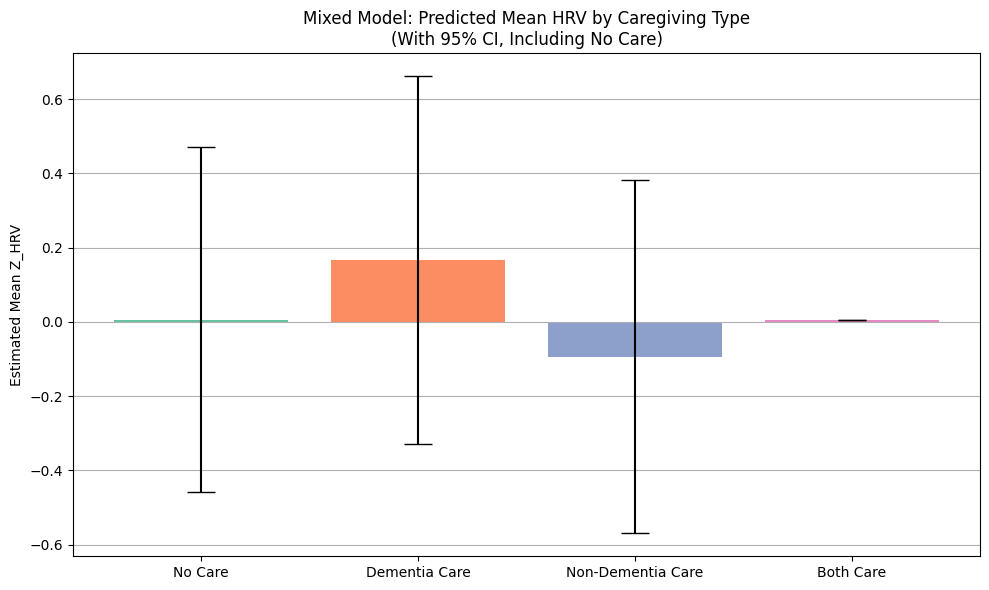

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import numpy as np

# Step 1: Preprocess data
df = df_dementia_caregiving.copy()

#df['Z_HRV'] = pd.to_numeric(df['Z_HRV'], errors='coerce')
##df['NDxCare'] = pd.to_numeric(df['NDxCare'], errors='coerce')
##df['BothCare'] = pd.to_numeric(df['BothCare'], errors='coerce')
df['NoCare'] = pd.to_numeric(df['NoCare'], errors='coerce')
df['ID'] = df['ID'].astype(str)

# Step 2: Define mutually exclusive caregiving type
def caregiving_type(row):
    if row['BothCare'] == 1:
        return 'Both Care'
    elif row['DxCare'] == 1:
        return 'Dementia Care'
    elif row['NDxCare'] == 1:
        return 'Non-Dementia Care'
    elif row['NoCare'] == 1:
        return 'No Care'
    else:
        return 'Unknown'

df['Care_Type'] = df.apply(caregiving_type, axis=1)

# Step 3: Clean data
df_clean = df[df['Care_Type'] != 'Unknown'][['ID', 'Z_HRV', 'Care_Type']].dropna()

# Step 4: Fit mixed model
model = smf.mixedlm("Z_HRV ~ C(Care_Type)", data=df_clean, groups=df_clean["ID"])
result = model.fit()
print(result.summary())

# Step 5: Extract model-predicted means and CI
care_types = ['No Care', 'Dementia Care', 'Non-Dementia Care', 'Both Care']
means = []
ci_lows = []
ci_highs = []

for ct in care_types:
    if ct == 'No Care':
        est = result.fe_params['Intercept']
        stderr = result.bse['Intercept']
    else:
        offset = result.fe_params.get(f'C(Care_Type)[T.{ct}]', 0)
        est = result.fe_params['Intercept'] + offset
        stderr = result.bse.get(f'C(Care_Type)[T.{ct}]', 0)

    ci_low = est - 1.96 * stderr
    ci_high = est + 1.96 * stderr

    means.append(est)
    ci_lows.append(ci_low)
    ci_highs.append(ci_high)

# Step 6: Plot
x = np.arange(len(care_types))
errors = np.array(means) - np.array(ci_lows)

plt.figure(figsize=(10, 6))
plt.bar(x, means, yerr=errors, capsize=10, color=sns.color_palette("Set2", len(x)))
plt.xticks(x, care_types)
plt.ylabel("Estimated Mean Z_HRV")
plt.title("Mixed Model: Predicted Mean HRV by Caregiving Type\n(With 95% CI, Including No Care)")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


                            OLS Regression Results                            
Dep. Variable:                  Z_HRV   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.6423
Date:                Sat, 25 Oct 2025   Prob (F-statistic):              0.424
Time:                        19:42:17   Log-Likelihood:                -272.28
No. Observations:                 198   AIC:                             548.6
Df Residuals:                     196   BIC:                             555.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0289      0.077     -0.373      0.7

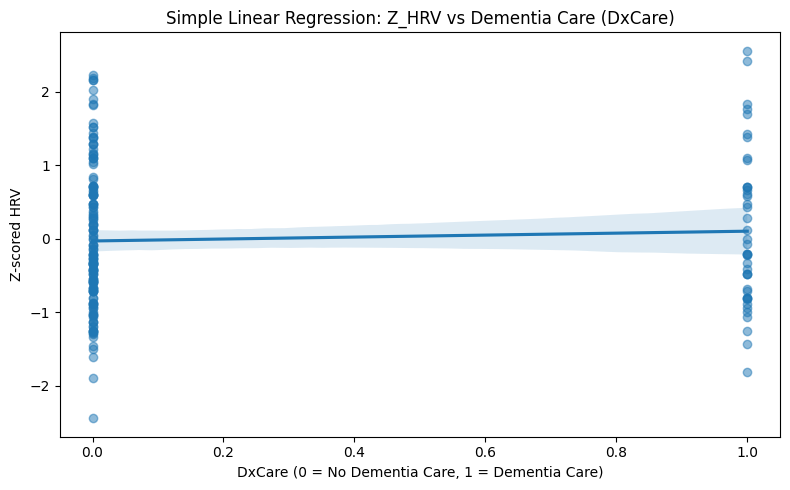

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf




# Drop missing values
df_simple = df[['DxCare', 'Z_HRV']]

# Fit simple linear regression model
simple_model = smf.ols("Z_HRV ~ DxCare", data=df_simple).fit()
print(simple_model.summary())

# Plot regression line
plt.figure(figsize=(8, 5))
sns.regplot(data=df_simple, x='DxCare', y='Z_HRV', ci=95, scatter_kws={'alpha': 0.5})
plt.title("Simple Linear Regression: Z_HRV vs Dementia Care (DxCare)")
plt.xlabel("DxCare (0 = No Dementia Care, 1 = Dementia Care)")
plt.ylabel("Z-scored HRV")
plt.tight_layout()
plt.show()


                            OLS Regression Results                            
Dep. Variable:                  Z_HRV   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.2255
Date:                Sat, 25 Oct 2025   Prob (F-statistic):              0.635
Time:                        19:42:21   Log-Likelihood:                -272.49
No. Observations:                 198   AIC:                             549.0
Df Residuals:                     196   BIC:                             555.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0209      0.081      0.257      0.7

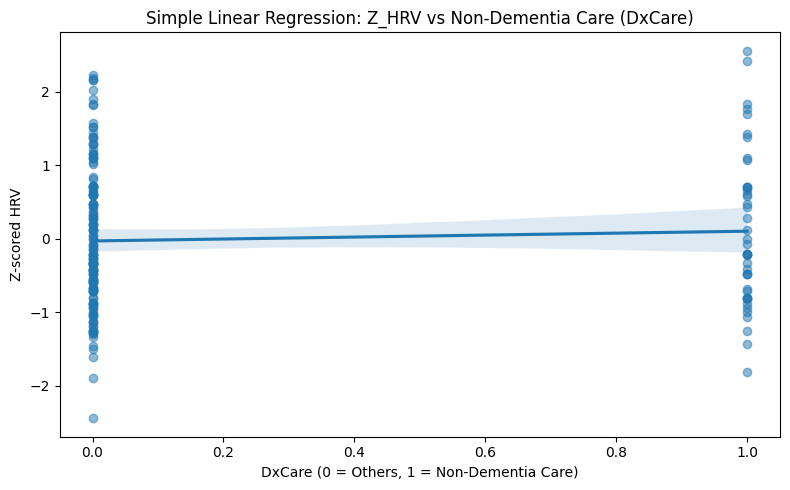

In [13]:
 #Drop missing values
df_simple_1 = df[['NDxCare', 'Z_HRV']]

# Fit simple linear regression model
simple_model = smf.ols("Z_HRV ~ NDxCare", data=df_simple_1).fit()
print(simple_model.summary())

# Plot regression line
plt.figure(figsize=(8, 5))
sns.regplot(data=df_simple, x='DxCare', y='Z_HRV', ci=95, scatter_kws={'alpha': 0.5})
plt.title("Simple Linear Regression: Z_HRV vs Non-Dementia Care (DxCare)")
plt.xlabel("DxCare (0 = Others, 1 = Non-Dementia Care)")
plt.ylabel("Z-scored HRV")
plt.tight_layout()
plt.show()

R-squared: 0.032
Intercept: 0.130
Coefficient: -0.606


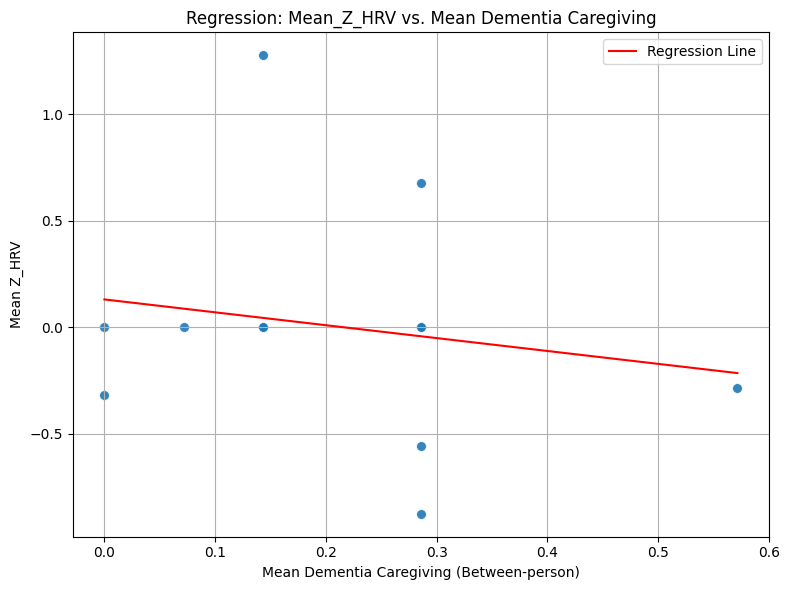

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Ensure DxCare_B is numeric
df['DxCare_B'] = pd.to_numeric(df['DxCare_B'], errors='coerce')
df['Z_HRV'] = pd.to_numeric(df['Z_HRV'], errors='coerce')

# Drop rows with missing values in relevant columns
df_avg_1 = df[['ID', 'Z_HRV', 'DxCare_B']].dropna()

#df_avg_1['Z_HRV'] = df_avg_1['Z_HRV'].abs()

df_summary_1 = df_avg_1.groupby('ID').agg({
    'Z_HRV': 'mean',
    'DxCare_B': 'mean'
}).reset_index()

df_mean_between = df_summary_1.rename(columns={
    'Z_HRV': 'Mean_Z_HRV',
    'DxCare_B': 'Mean_Dementia_Caregiving_Between'
})

# Define X and y
X = df_mean_between[['Mean_Dementia_Caregiving_Between']]  # 2D
y = df_mean_between['Mean_Z_HRV']

# Fit Linear Regression
model = LinearRegression()
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

# Evaluation metrics
r2 = r2_score(y, y_pred)
print(f"R-squared: {r2:.3f}")
print(f"Intercept: {model.intercept_:.3f}")
print(f"Coefficient: {model.coef_[0]:.3f}")

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Mean_Dementia_Caregiving_Between', y='Mean_Z_HRV', data=df_mean_between, s=50, alpha=0.9)
sns.lineplot(x=df_mean_between['Mean_Dementia_Caregiving_Between'], y=y_pred, color='red', label='Regression Line')
plt.title('Regression: Mean_Z_HRV vs. Mean Dementia Caregiving')
plt.xlabel('Mean Dementia Caregiving (Between-person)')
plt.ylabel('Mean Z_HRV')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
df_avg_1

In [ ]:
df_summary_1

In [ ]:
df.columns

R-squared : 0.073
Intercept : 0.645
Coefficient: -1.771


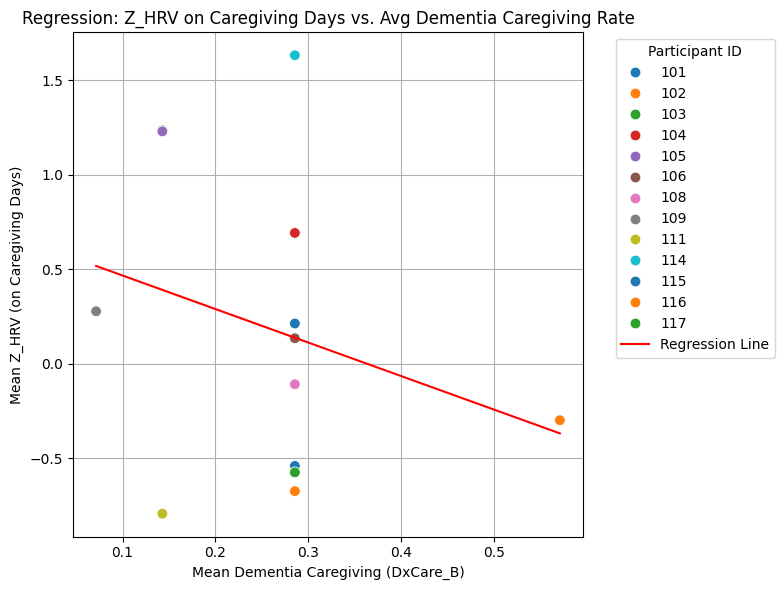

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ---------------------------
# Prepare data
# ---------------------------
df_care_days = df[['ID', 'Day', 'DxCare_B', 'Z_HRV', 'DxCare']].dropna().copy()

# absolute Z_HRV
#df_care_days['Z_HRV'] = df_care_days['Z_HRV'].abs()

# keep only caregiving days
df_care_days = df_care_days[df_care_days['DxCare'] == 1].copy()

# summary per participant (mean caregiving & mean |Z_HRV|)
df_care_summary = (
    df_care_days
    .groupby('ID')
    .agg({
        'DxCare_B': 'mean',
        'Z_HRV': 'mean'
    })
    .reset_index()
    .rename(columns={
        'DxCare_B': 'Mean_DxCare_B_onCareDays',
        'Z_HRV': 'Mean_Z_HRV_onCareDays'
    })
)

# ---------------------------
# Regression
# ---------------------------
X = df_care_summary[['Mean_DxCare_B_onCareDays']]
y = df_care_summary['Mean_Z_HRV_onCareDays']

model = LinearRegression().fit(X, y)
y_pred = model.predict(X)

print(f"R-squared : {r2_score(y, y_pred):.3f}")
print(f"Intercept : {model.intercept_:.3f}")
print(f"Coefficient: {model.coef_[0]:.3f}")

# ---------------------------
# Plot with color-coded IDs
# ---------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_care_summary,
    x='Mean_DxCare_B_onCareDays',
    y='Mean_Z_HRV_onCareDays',
    hue='ID',            # color by participant
    palette='tab10',
    s=60
)

# regression line
sns.lineplot(
    x=df_care_summary['Mean_DxCare_B_onCareDays'],
    y=y_pred,
    color='red',
    label='Regression Line'
)

plt.title('Regression: Z_HRV on Caregiving Days vs. Avg Dementia Caregiving Rate')
plt.xlabel('Mean Dementia Caregiving (DxCare_B)')
plt.ylabel('Mean Z_HRV (on Caregiving Days)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Participant ID')
plt.tight_layout()
plt.show()


In [16]:
df_care_summary

,ID,Mean_DxCare_B_onCareDays,Mean_Z_HRV_onCareDays
0,101,0.285714,0.213771
1,102,0.285714,-0.673427
2,103,0.142857,1.235868
3,104,0.285714,0.692902
4,105,0.142857,1.230042
5,106,0.285714,0.135613
6,108,0.285714,-0.107777
7,109,0.071429,0.278605
8,111,0.142857,-0.792317
9,114,0.285714,1.632940


R-squared: 0.103
Intercept: -0.582
Coefficient: 1.221


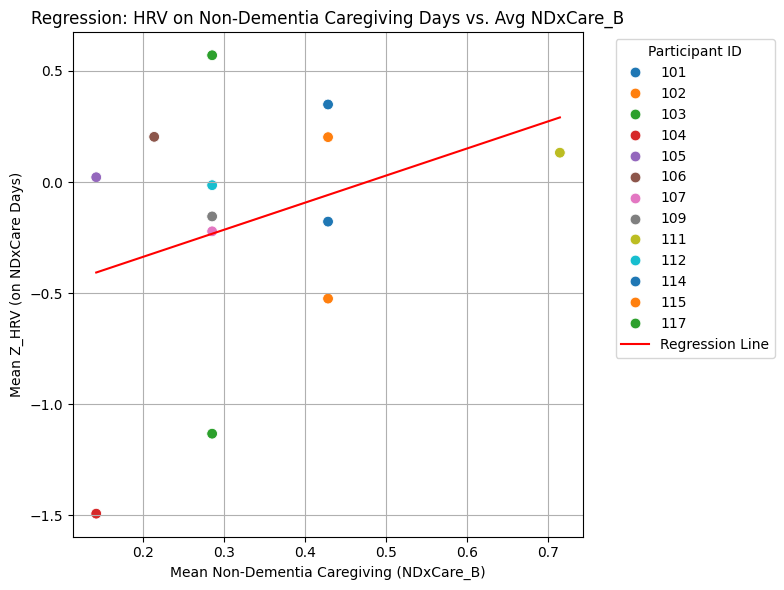

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Step 1: Prepare the data
df['NDxCare_B'] = pd.to_numeric(df['NDxCare_B'], errors='coerce')
df_care_days_NDX = df[['ID', 'Day', 'NDxCare_B', 'Z_HRV', 'NDxCare']].dropna().copy()

# Filter only caregiving days and take absolute Z_HRV
df_care_days_NDX = df_care_days_NDX[df_care_days_NDX['NDxCare'] == 1].copy()
#df_care_days_NDX['Z_HRV'] = df_care_days_NDX['Z_HRV'].abs()

# Step 2: Group by participant
df_care_summary_Nd = df_care_days_NDX.groupby('ID').agg({
    'NDxCare_B': 'mean',
    'Z_HRV': 'mean'
}).reset_index()

# Rename columns for clarity
df_care_summary_Nd = df_care_summary_Nd.rename(columns={
    'NDxCare_B': 'Mean_NDxCare_B_onCareDays',
    'Z_HRV': 'Mean_Z_HRV_onNonDemCareDays'
})

# Step 3: Define X and y
X = df_care_summary_Nd[['Mean_NDxCare_B_onCareDays']]
y = df_care_summary_Nd['Mean_Z_HRV_onNonDemCareDays']

# Step 4: Fit linear regression
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Step 5: Evaluation
print(f"R-squared: {r2_score(y, y_pred):.3f}")
print(f"Intercept: {model.intercept_:.3f}")
print(f"Coefficient: {model.coef_[0]:.3f}")

# Step 6: Plot with color-coded participants
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_care_summary_Nd,
    x='Mean_NDxCare_B_onCareDays',
    y='Mean_Z_HRV_onNonDemCareDays',
    hue='ID',
    palette='tab10',
    s=60
)

# Regression line (same for all participants)
sns.lineplot(
    x=df_care_summary_Nd['Mean_NDxCare_B_onCareDays'],
    y=y_pred,
    color='red',
    label='Regression Line'
)

plt.title('Regression: HRV on Non-Dementia Caregiving Days vs. Avg NDxCare_B')
plt.xlabel('Mean Non-Dementia Caregiving (NDxCare_B)')
plt.ylabel('Mean Z_HRV (on NDxCare Days)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Participant ID")
plt.tight_layout()
plt.show()


In [18]:
df_care_days_NDX

,ID,Day,NDxCare_B,Z_HRV,NDxCare
0,101,0,0.428571,1.104485,1
2,101,2,0.428571,0.035629,1
3,101,3,0.428571,-0.320657,1
9,101,9,0.428571,-0.676942,1
10,101,10,0.428571,-1.033228,1
17,102,2,0.428571,0.665504,1
19,102,4,0.428571,-0.261448,1
21,102,6,0.428571,-0.879417,1
24,102,9,0.428571,1.283473,1
26,102,11,0.428571,1.283473,1


R-squared: 0.000
Intercept: -0.110
Coefficient: 0.026


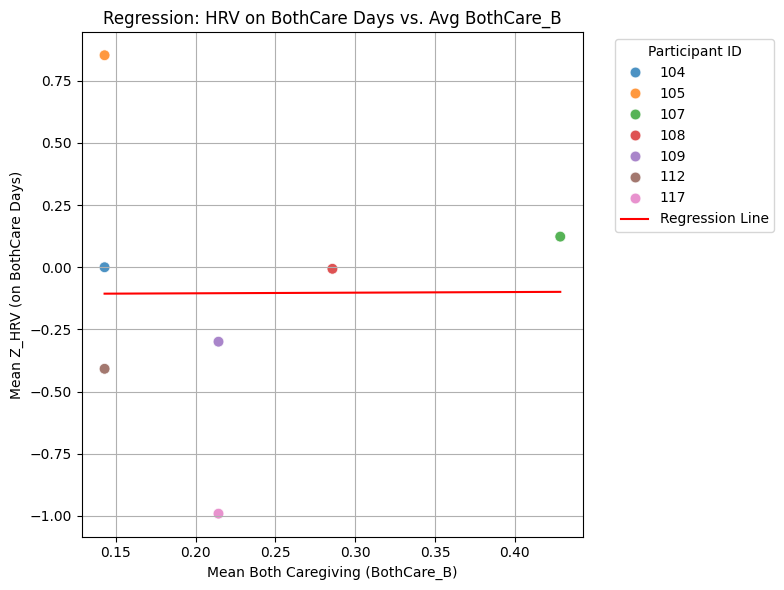

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Prepare the data
df['BothCare_B'] = pd.to_numeric(df['BothCare_B'], errors='coerce')
df_care_days_BothCare = df[['ID', 'Day', 'BothCare_B', 'Z_HRV', 'BothCare']].dropna().copy()
df_care_days_BothCare = df_care_days_BothCare[df_care_days_BothCare['BothCare'] == 1].copy()
#df_care_days_BothCare['Z_HRV'] = df_care_days_BothCare['Z_HRV'].abs()

# Group by participant
df_care_summary_Both = df_care_days_BothCare.groupby('ID').agg({
    'BothCare_B': 'mean',
    'Z_HRV': 'mean'
}).reset_index()

# Rename columns
df_care_summary_Both = df_care_summary_Both.rename(columns={
    'BothCare_B': 'Mean_BothCare_B',
    'Z_HRV': 'Mean_Z_HRV_onBothCare'
})

# Define X and y
X = df_care_summary_Both[['Mean_BothCare_B']]
y = df_care_summary_Both['Mean_Z_HRV_onBothCare']

# Fit the regression model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Print evaluation
print(f"R-squared: {r2_score(y, y_pred):.3f}")
print(f"Intercept: {model.intercept_:.3f}")
print(f"Coefficient: {model.coef_[0]:.3f}")

# Sort for smooth regression line
df_sorted = df_care_summary_Both.sort_values('Mean_BothCare_B')
X_sorted = df_sorted[['Mean_BothCare_B']]
y_pred_sorted = model.predict(X_sorted)

# Plot with hue
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_care_summary_Both,
    x='Mean_BothCare_B',
    y='Mean_Z_HRV_onBothCare',
    hue='ID',
    palette='tab10',
    s=60,
    alpha=0.8
)
plt.plot(X_sorted['Mean_BothCare_B'], y_pred_sorted, color='red', label='Regression Line')
plt.title('Regression: HRV on BothCare Days vs. Avg BothCare_B')
plt.xlabel('Mean Both Caregiving (BothCare_B)')
plt.ylabel('Mean Z_HRV (on BothCare Days)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Participant ID')
plt.tight_layout()
plt.show()


R-squared: 0.041
Intercept: -0.357
Coefficient: 0.857


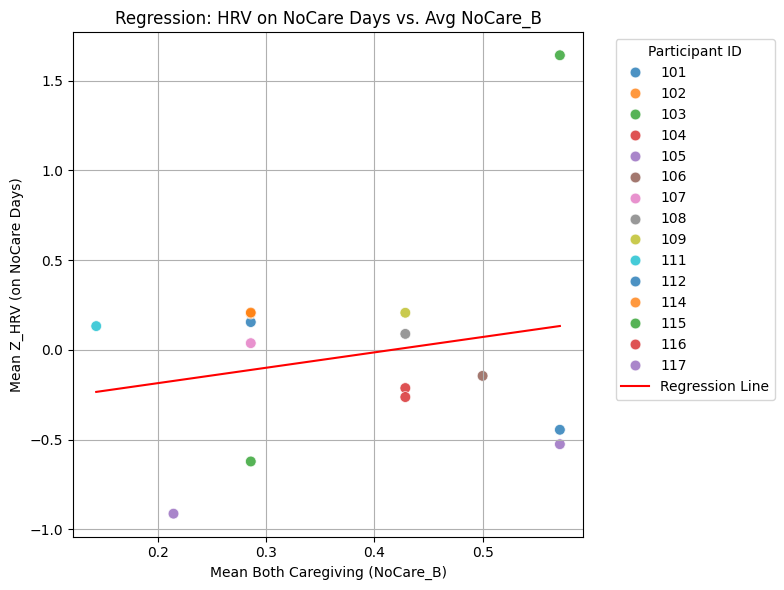

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Prepare the data
df['NoCare_B'] = pd.to_numeric(df['NoCare_B'], errors='coerce')
df_care_days_NoCare = df[['ID', 'Day', 'NoCare_B', 'Z_HRV', 'NoCare']].dropna().copy()
df_care_days_NoCare = df_care_days_NoCare[df_care_days_NoCare['NoCare'] == 1].copy()
#df_care_days_NoCare['Z_HRV'] = df_care_days_NoCare['Z_HRV'].abs()

# Group by participant
df_Nocare_summary_Both = df_care_days_NoCare.groupby('ID').agg({
    'NoCare_B': 'mean',
    'Z_HRV': 'mean'
}).reset_index()

# Rename columns
df_Nocare_summary_Both = df_Nocare_summary_Both.rename(columns={
    'NoCare_B': 'Mean_NoCare_B',
    'Z_HRV': 'Mean_Z_HRV_onNoCare'
})

# Define X and y
X = df_Nocare_summary_Both[['Mean_NoCare_B']]
y = df_Nocare_summary_Both['Mean_Z_HRV_onNoCare']

# Fit the regression model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Print evaluation
print(f"R-squared: {r2_score(y, y_pred):.3f}")
print(f"Intercept: {model.intercept_:.3f}")
print(f"Coefficient: {model.coef_[0]:.3f}")

# Sort for smooth regression line
df_sorted = df_Nocare_summary_Both.sort_values('Mean_NoCare_B')
X_sorted = df_sorted[['Mean_NoCare_B']]
y_pred_sorted = model.predict(X_sorted)

# Plot with hue
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_Nocare_summary_Both,
    x='Mean_NoCare_B',
    y='Mean_Z_HRV_onNoCare',
    hue='ID',
    palette='tab10',
    s=60,
    alpha=0.8
)
plt.plot(X_sorted['Mean_NoCare_B'], y_pred_sorted, color='red', label='Regression Line')
plt.title('Regression: HRV on NoCare Days vs. Avg NoCare_B')
plt.xlabel('Mean Both Caregiving (NoCare_B)')
plt.ylabel('Mean Z_HRV (on NoCare Days)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Participant ID')
plt.tight_layout()
plt.show()

R-squared: 0.073
Intercept: -1.127
Coefficient: 1.771


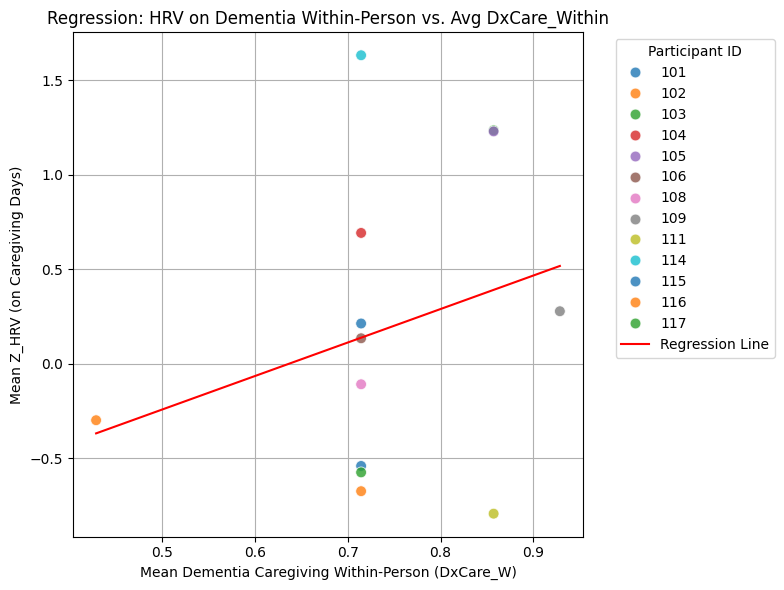

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Step 0: Prepare data
df['DxCare_W'] = pd.to_numeric(df['DxCare_W'], errors='coerce')

df_care_days_Within = df[['ID', 'Day', 'DxCare_W', 'Z_HRV', 'DxCare']].dropna().copy()
df_care_days_Within = df_care_days_Within[df_care_days_Within['DxCare'] == 1].copy()
#df_care_days_Within['Z_HRV'] = df_care_days_Within['Z_HRV'].abs()

# Step 1: Group by participant and compute mean
df_care_summary_Within = df_care_days_Within.groupby('ID').agg({
    'DxCare_W': 'mean',
    'Z_HRV': 'mean'
}).reset_index()

df_care_summary_Within = df_care_summary_Within.rename(columns={
    'DxCare_W': 'Mean_DxCare_W',
    'Z_HRV': 'Mean_Z_HRV_W'
})

# Step 2: Define X and y
X = df_care_summary_Within[['Mean_DxCare_W']]
y = df_care_summary_Within['Mean_Z_HRV_W']

# Step 3: Fit the model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Step 4: Evaluation
print(f"R-squared: {r2_score(y, y_pred):.3f}")
print(f"Intercept: {model.intercept_:.3f}")
print(f"Coefficient: {model.coef_[0]:.3f}")

# Step 5: Sort for smooth regression line
df_sorted = df_care_summary_Within.sort_values('Mean_DxCare_W')
X_sorted = df_sorted[['Mean_DxCare_W']]
y_pred_sorted = model.predict(X_sorted)

# Step 6: Plot with hue by participant ID
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_care_summary_Within,
    x='Mean_DxCare_W',
    y='Mean_Z_HRV_W',
    hue='ID',
    palette='tab10',
    s=60,
    alpha=0.8
)

plt.plot(X_sorted['Mean_DxCare_W'], y_pred_sorted, color='red', label='Regression Line')
plt.title('Regression: HRV on Dementia Within-Person vs. Avg DxCare_Within')
plt.xlabel('Mean Dementia Caregiving Within-Person (DxCare_W)')
plt.ylabel('Mean Z_HRV (on Caregiving Days)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Participant ID")
plt.tight_layout()
plt.show()


In [22]:
df_care_summary_Within

,ID,Mean_DxCare_W,Mean_Z_HRV_W
0,101,0.714286,0.213771
1,102,0.714286,-0.673427
2,103,0.857143,1.235868
3,104,0.714286,0.692902
4,105,0.857143,1.230042
5,106,0.714286,0.135613
6,108,0.714286,-0.107777
7,109,0.928571,0.278605
8,111,0.857143,-0.792317
9,114,0.714286,1.632940


In [23]:
df_sorted

,ID,Mean_DxCare_W,Mean_Z_HRV_W
11,116,0.428571,-0.297946
0,101,0.714286,0.213771
3,104,0.714286,0.692902
1,102,0.714286,-0.673427
6,108,0.714286,-0.107777
10,115,0.714286,-0.539924
9,114,0.714286,1.632940
5,106,0.714286,0.135613
12,117,0.714286,-0.573849
8,111,0.857143,-0.792317


R-squared: 0.103
Intercept: 0.640
Coefficient: -1.221


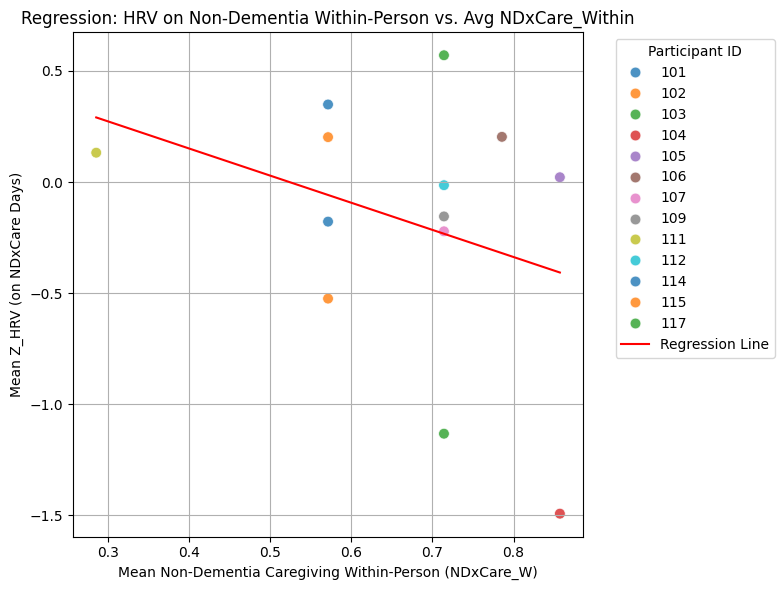

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Step 0: Prepare data
df['NDxCare_W'] = pd.to_numeric(df['NDxCare_W'], errors='coerce')

df_Ndxcare_days_Within = df[['ID', 'Day', 'NDxCare_W', 'Z_HRV', 'NDxCare']].dropna().copy()
df_Ndxcare_days_Within = df_Ndxcare_days_Within[df_Ndxcare_days_Within['NDxCare'] == 1].copy()
#df_Ndxcare_days_Within['Z_HRV'] = df_Ndxcare_days_Within['Z_HRV'].abs()

# Step 1: Group by participant and compute mean
df_Ndxcare_summary_Within = df_Ndxcare_days_Within.groupby('ID').agg({
    'NDxCare_W': 'mean',
    'Z_HRV': 'mean'
}).reset_index()

df_Ndxcare_summary_Within = df_Ndxcare_summary_Within.rename(columns={
    'NDxCare_W': 'Mean_NDxCare_W',
    'Z_HRV': 'Mean_Z_HRV_W'
})

# Step 2: Define X and y
X = df_Ndxcare_summary_Within[['Mean_NDxCare_W']]
y = df_Ndxcare_summary_Within['Mean_Z_HRV_W']

# Step 3: Fit the model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Step 4: Evaluation
print(f"R-squared: {r2_score(y, y_pred):.3f}")
print(f"Intercept: {model.intercept_:.3f}")
print(f"Coefficient: {model.coef_[0]:.3f}")

# Step 5: Sort for cleaner regression line
df_sorted = df_Ndxcare_summary_Within.sort_values('Mean_NDxCare_W')
X_sorted = df_sorted[['Mean_NDxCare_W']]
y_pred_sorted = model.predict(X_sorted)

# Step 6: Plot with color by participant ID
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_Ndxcare_summary_Within,
    x='Mean_NDxCare_W',
    y='Mean_Z_HRV_W',
    hue='ID',
    palette='tab10',
    s=60,
    alpha=0.8
)

plt.plot(X_sorted['Mean_NDxCare_W'], y_pred_sorted, color='red', label='Regression Line')
plt.title('Regression: HRV on Non-Dementia Within-Person vs. Avg NDxCare_Within')
plt.xlabel('Mean Non-Dementia Caregiving Within-Person (NDxCare_W)')
plt.ylabel('Mean Z_HRV (on NDxCare Days)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Participant ID")
plt.tight_layout()
plt.show()


In [25]:
df_Ndxcare_days_Within
df_Ndxcare_days_Within.isna()

,ID,Day,NDxCare_W,Z_HRV,NDxCare
0,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
9,False,False,False,False,False
10,False,False,False,False,False
17,False,False,False,False,False
19,False,False,False,False,False
21,False,False,False,False,False
24,False,False,False,False,False
26,False,False,False,False,False


R-squared: 0.000
Intercept: -0.084
Coefficient: -0.026


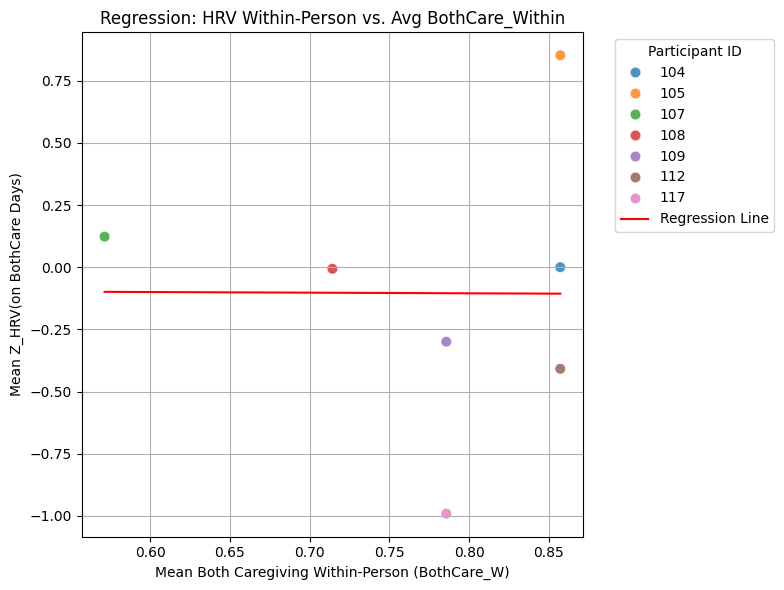

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Step 0: Prepare data
df['BothCare_W'] = pd.to_numeric(df['BothCare_W'], errors='coerce')

df_Bothcare_days_Within = df[['ID', 'Day', 'BothCare_W', 'Z_HRV', 'BothCare']].dropna().copy()
df_Bothcare_days_Within = df_Bothcare_days_Within[df_Bothcare_days_Within['BothCare'] == 1].copy()
#df_Bothcare_days_Within['Z_HRV'] = df_Bothcare_days_Within['Z_HRV'].abs()

# Step 1: Group by participant and compute mean
df_Bothcare_summary_Within = df_Bothcare_days_Within.groupby('ID').agg({
    'BothCare_W': 'mean',
    'Z_HRV': 'mean'
}).reset_index()

df_Bothcare_summary_Within = df_Bothcare_summary_Within.rename(columns={
    'BothCare_W': 'Mean_BothCare_W',
    'Z_HRV': 'Mean_Z_HRV_W'
})

# Step 2: Define X and y
X = df_Bothcare_summary_Within[['Mean_BothCare_W']]
y = df_Bothcare_summary_Within['Mean_Z_HRV_W']

# Step 3: Fit the model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Step 4: Evaluation
print(f"R-squared: {r2_score(y, y_pred):.3f}")
print(f"Intercept: {model.intercept_:.3f}")
print(f"Coefficient: {model.coef_[0]:.3f}")

# Step 5: Sort for smooth regression line
df_sorted = df_Bothcare_summary_Within.sort_values('Mean_BothCare_W')
X_sorted = df_sorted[['Mean_BothCare_W']]
y_pred_sorted = model.predict(X_sorted)

# Step 6: Plot with hue by ID
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_Bothcare_summary_Within,
    x='Mean_BothCare_W',
    y='Mean_Z_HRV_W',
    hue='ID',
    palette='tab10',
    s=60,
    alpha=0.8
)
plt.plot(X_sorted['Mean_BothCare_W'], y_pred_sorted, color='red', label='Regression Line')
plt.title('Regression: HRV Within-Person vs. Avg BothCare_Within')
plt.xlabel('Mean Both Caregiving Within-Person (BothCare_W)')
plt.ylabel('Mean Z_HRV(on BothCare Days)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Participant ID")
plt.tight_layout()
plt.show()


In [27]:
df_Bothcare_summary_Within

,ID,Mean_BothCare_W,Mean_Z_HRV_W
0,104,0.857143,0.000000
1,105,0.857143,0.852398
2,107,0.571429,0.123218
3,108,0.714286,-0.006159
4,109,0.785714,-0.299242
5,112,0.857143,-0.408235
6,117,0.785714,-0.990717


R-squared: 0.041
Intercept: 0.500
Coefficient: -0.857


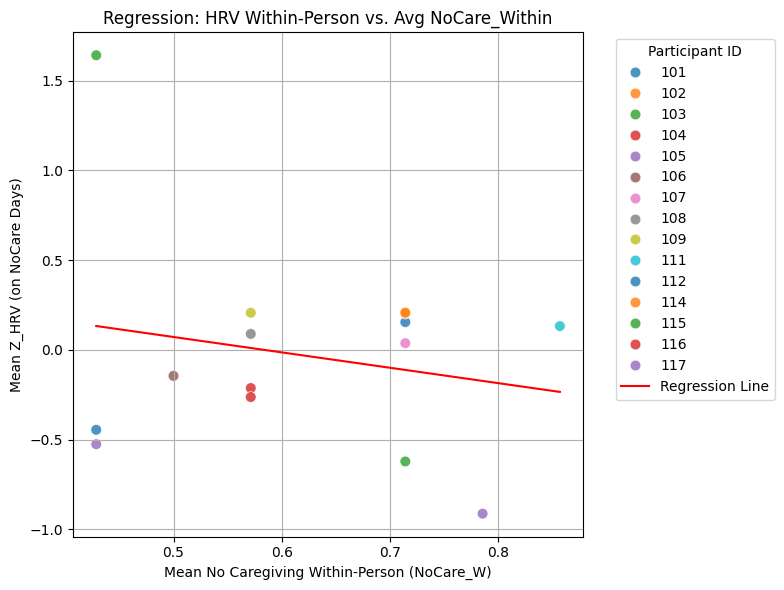

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Step 0: Prepare data
df['NoCare_W'] = pd.to_numeric(df['NoCare_W'], errors='coerce')

df_Nocare_days_Within = df[['ID', 'Day', 'NoCare_W', 'Z_HRV', 'NoCare']].dropna().copy()
df_Nocare_days_Within = df_Nocare_days_Within[df_Nocare_days_Within['NoCare'] == 1].copy()
#df_Nocare_days_Within['Z_HRV'] = df_Nocare_days_Within['Z_HRV'].abs()

# Step 1: Group by participant and compute mean
df_Nocare_summary_Within = df_Nocare_days_Within.groupby('ID').agg({
    'NoCare_W': 'mean',
    'Z_HRV': 'mean'
}).reset_index()

df_Nocare_summary_Within = df_Nocare_summary_Within.rename(columns={
    'NoCare_W': 'Mean_NoCare_W',
    'Z_HRV': 'Mean_Z_HRV_W'
})

# Step 2: Define X and y
X = df_Nocare_summary_Within[['Mean_NoCare_W']]
y = df_Nocare_summary_Within['Mean_Z_HRV_W']

# Step 3: Fit the model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Step 4: Evaluation
print(f"R-squared: {r2_score(y, y_pred):.3f}")
print(f"Intercept: {model.intercept_:.3f}")
print(f"Coefficient: {model.coef_[0]:.3f}")

# Step 5: Sort values for clean regression line
df_sorted = df_Nocare_summary_Within.sort_values('Mean_NoCare_W')
X_sorted = df_sorted[['Mean_NoCare_W']]
y_pred_sorted = model.predict(X_sorted)

# Step 6: Plot with color-coded participant IDs
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_Nocare_summary_Within,
    x='Mean_NoCare_W',
    y='Mean_Z_HRV_W',
    hue='ID',
    palette='tab10',
    s=60,
    alpha=0.8
)

plt.plot(X_sorted['Mean_NoCare_W'], y_pred_sorted, color='red', label='Regression Line')
plt.title('Regression: HRV Within-Person vs. Avg NoCare_Within')
plt.xlabel('Mean No Caregiving Within-Person (NoCare_W)')
plt.ylabel('Mean Z_HRV (on NoCare Days)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Participant ID')
plt.tight_layout()
plt.show()


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Z_HRV    
No. Observations: 198     Method:             REML     
No. Groups:       15      Scale:              0.7366   
Min. group size:  10      Log-Likelihood:     -261.7684
Max. group size:  14      Converged:          Yes      
Mean group size:  13.2                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    -0.002    0.131 -0.018 0.986 -0.258  0.254
DxCare_W      0.245    0.159  1.543 0.123 -0.066  0.556
Ce_DxCare_B  -0.612    0.930 -0.658 0.510 -2.434  1.210
Group Var     0.200    0.120                           



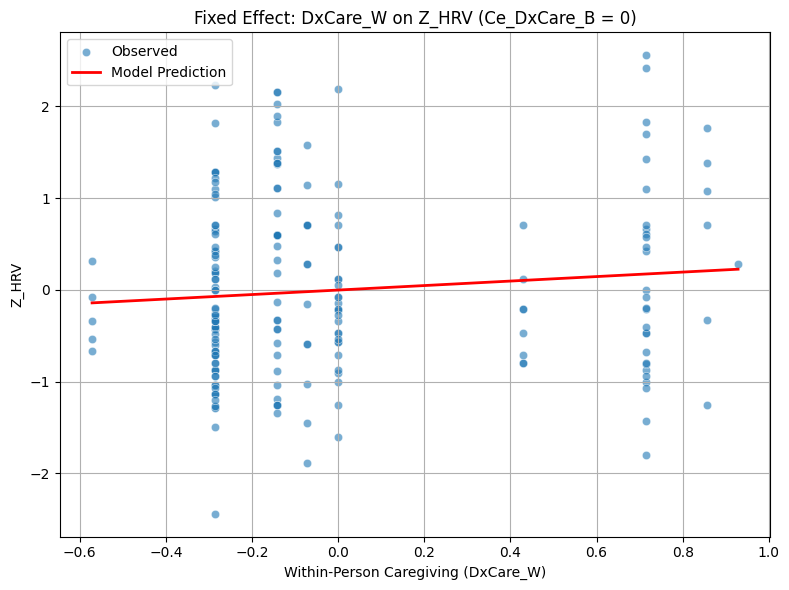

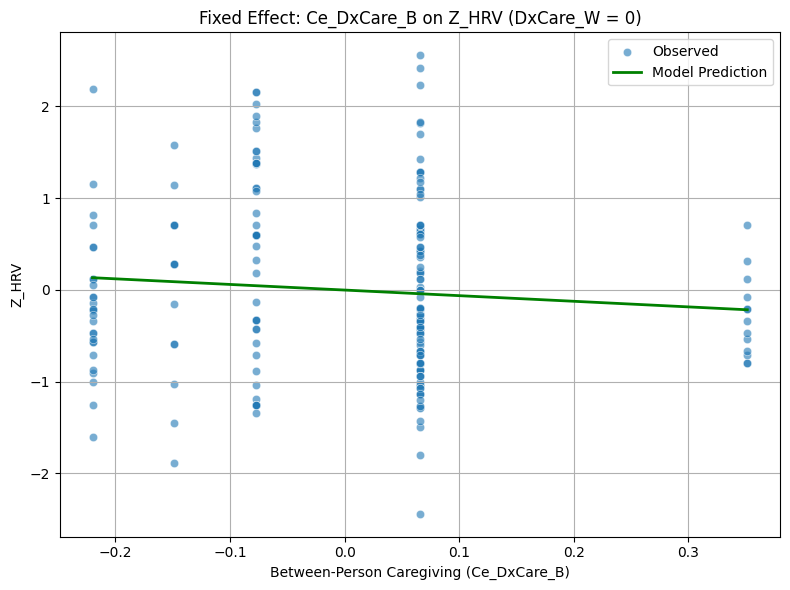

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Step 1: Ensure correct data types
df['DxCare_W'] = pd.to_numeric(df['DxCare_W'], errors='coerce')
df['Ce_DxCare_B'] = pd.to_numeric(df['Ce_DxCare_B'], errors='coerce')
df['Z_HRV'] = pd.to_numeric(df['Z_HRV'], errors='coerce')
df['ID'] = df['ID'].astype(str)

# Step 2: Drop rows with missing values
df_model = df[['Z_HRV', 'DxCare_W', 'Ce_DxCare_B', 'ID']].dropna().copy()

# Step 3: Fit the mixed-effects model
model = smf.mixedlm("Z_HRV ~ DxCare_W + Ce_DxCare_B", data=df_model, groups=df_model["ID"])
result = model.fit()
print(result.summary())

# Step 4: Plot fixed effect of DxCare_W (within-person)
x_vals_within = np.linspace(df_model['DxCare_W'].min(), df_model['DxCare_W'].max(), 100)
X_plot_within = pd.DataFrame({
    'DxCare_W': x_vals_within,
    'Ce_DxCare_B': 0,  # hold between-person caregiving at average (centered)
    'ID': 'dummy'  # dummy group to satisfy model requirement
})
X_plot_within['Z_HRV_Pred'] = result.predict(X_plot_within)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_model, x='DxCare_W', y='Z_HRV', alpha=0.6, label='Observed')
plt.plot(X_plot_within['DxCare_W'], X_plot_within['Z_HRV_Pred'], color='red', linewidth=2, label='Model Prediction')
plt.xlabel('Within-Person Caregiving (DxCare_W)')
plt.ylabel('Z_HRV')
plt.title('Fixed Effect: DxCare_W on Z_HRV (Ce_DxCare_B = 0)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Step 5: Plot fixed effect of Ce_DxCare_B (between-person)
x_vals_between = np.linspace(df_model['Ce_DxCare_B'].min(), df_model['Ce_DxCare_B'].max(), 100)
X_plot_between = pd.DataFrame({
    'DxCare_W': 0,  # hold within-person caregiving at average
    'Ce_DxCare_B': x_vals_between,
    'ID': 'dummy'
})
X_plot_between['Z_HRV_Pred'] = result.predict(X_plot_between)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_model, x='Ce_DxCare_B', y='Z_HRV', alpha=0.6, label='Observed')
plt.plot(X_plot_between['Ce_DxCare_B'], X_plot_between['Z_HRV_Pred'], color='green', linewidth=2, label='Model Prediction')
plt.xlabel('Between-Person Caregiving (Ce_DxCare_B)')
plt.ylabel('Z_HRV')
plt.title('Fixed Effect: Ce_DxCare_B on Z_HRV (DxCare_W = 0)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [30]:
from scipy.stats import f_oneway
import pandas as pd

# Map caregiving types to their associated variables
care_map = {
    'DxCare':   ['DxCare_W', 'DxCare_B'],
    'NDxCare':  ['NDxCare_W', 'NDxCare_B'],
    'BothCare': ['BothCare_W', 'BothCare_B'],
    'NoCare':   ['NoCare_B']  # Assuming NoCare_W doesn't exist
}

# Ensure Z_HRV is numeric
df['Z_HRV'] = pd.to_numeric(df['Z_HRV'], errors='coerce')

# Loop over each care group and run ANOVA on its variables (without any filtering)
for care_type, variables in care_map.items():
    print(f"\n🟦 One-Way ANOVA for {care_type}-related variables: {', '.join(variables)}")

    for var in variables:
        df[var] = pd.to_numeric(df[var], errors='coerce')
        subset = df[[var, 'Z_HRV']].dropna()

        # Bin the variable into discrete groups (if continuous)
        if subset[var].nunique() > 10:  # Assume continuous, bin into quartiles
            subset['group'] = pd.qcut(subset[var], q=4, duplicates='drop')
        else:
            subset['group'] = subset[var]

        # Group HRV by variable levels
        hrv_groups = [group['Z_HRV'].values for name, group in subset.groupby('group') if len(group) > 1]

        # Run ANOVA if 2+ groups exist
        if len(hrv_groups) >= 2:
            f_stat, p_val = f_oneway(*hrv_groups)
            print(f"  ✅ {var}: F = {f_stat:.3f}, p = {p_val:.4f}", end=' ')
            if p_val < 0.05:
                print("→ Statistically significant ✅")
            else:
                print("→ Not significant ❌")
        else:
            print(f"  ⚠️ Skipped {var}: not enough valid groups for ANOVA.")



🟦 One-Way ANOVA for DxCare-related variables: DxCare_W, DxCare_B
  ✅ DxCare_W: F = 1.938, p = 0.0658 → Not significant ❌
  ✅ DxCare_B: F = 2.898, p = 0.0232 → Statistically significant ✅

🟦 One-Way ANOVA for NDxCare-related variables: NDxCare_W, NDxCare_B
  ✅ NDxCare_W: F = 0.347, p = 0.7911 → Not significant ❌
  ✅ NDxCare_B: F = 0.145, p = 0.9813 → Not significant ❌

🟦 One-Way ANOVA for BothCare-related variables: BothCare_W, BothCare_B
  ✅ BothCare_W: F = 1.185, p = 0.3102 → Not significant ❌
  ✅ BothCare_B: F = 2.128, p = 0.0789 → Not significant ❌

🟦 One-Way ANOVA for NoCare-related variables: NoCare_B
  ✅ NoCare_B: F = 3.354, p = 0.0063 → Statistically significant ✅


/tmp/ipython-input-1346056941.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hrv_groups = [group['Z_HRV'].values for name, group in subset.groupby('group') if len(group) > 1]


In [31]:
from scipy.stats import pearsonr
import pandas as pd

# Ensure Z_HRV is numeric
df['Z_HRV'] = pd.to_numeric(df['Z_HRV'], errors='coerce')

# Define caregiving variables
caregiving_vars = [
  'DxCG_Hrs_B',
  'NonDxCG_Hrs_B',
  'DxCG_Hrs_W',
  'NonDxCG_Hrs_W',
  'Caregiving_Hrs_Total'


]

# Ensure all caregiving variables are numeric
for var in caregiving_vars:
    df[var] = pd.to_numeric(df[var], errors='coerce')


# Drop rows with missing Z_HRV
df_corr = df[['Z_HRV'] + caregiving_vars].dropna()

# Store results
correlation_results = []

for var in caregiving_vars:
    r, p = pearsonr(df_corr['Z_HRV'], df_corr[var])
    correlation_results.append({
        'Caregiving Variable': var,
        'Pearson r': round(r, 3),
        'p-value': round(p, 5),
        'Significance': '✅' if p < 0.05 else '❌'
    })

# Convert to DataFrame
correlation_df = pd.DataFrame(correlation_results)

# Display
print(correlation_df)

    Caregiving Variable  Pearson r  p-value Significance
0            DxCG_Hrs_B     -0.228  0.00125            ✅
1         NonDxCG_Hrs_B     -0.158  0.02599            ✅
2            DxCG_Hrs_W      0.083  0.24249            ❌
3         NonDxCG_Hrs_W     -0.019  0.79063            ❌
4  Caregiving_Hrs_Total     -0.070  0.32669            ❌


In [32]:
import statsmodels.api as sm
import pandas as pd

# Ensure the data is numeric (repeating for completeness)
df['Z_HRV'] = pd.to_numeric(df['Z_HRV'], errors='coerce')
for var in caregiving_vars:
    df[var] = pd.to_numeric(df[var], errors='coerce')

# Drop missing values
df_reg = df[['Z_HRV'] + caregiving_vars].dropna()

# Define dependent and independent variables
X = df_reg[caregiving_vars]
y = df_reg['Z_HRV']

# Add constant (intercept)
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Show the summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Z_HRV   R-squared:                       0.106
Model:                            OLS   Adj. R-squared:                  0.087
Method:                 Least Squares   F-statistic:                     5.701
Date:                Sat, 25 Oct 2025   Prob (F-statistic):           0.000234
Time:                        19:43:22   Log-Likelihood:                -261.55
No. Observations:                 198   AIC:                             533.1
Df Residuals:                     193   BIC:                             549.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.9175 

In [33]:
import statsmodels.api as sm
import pandas as pd

caregiving_vars_1 =['DxCare_W', 'DxCare_B','BothCare_W', 'BothCare_B', 'NoCare_B','NDxCare_W', 'NDxCare_B' ]


# Ensure the data is numeric (repeating for completeness)
df['Z_HRV'] = pd.to_numeric(df['Z_HRV'], errors='coerce')
for var in caregiving_vars_1:
    df[var] = pd.to_numeric(df[var], errors='coerce')

# Drop missing values
df_reg = df[['Z_HRV'] + caregiving_vars_1].dropna()

# Define dependent and independent variables
X = df_reg[caregiving_vars_1]
y = df_reg['Z_HRV']

# Add constant (intercept)
X = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X).fit()

# Show the summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Z_HRV   R-squared:                       0.075
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     2.595
Date:                Sat, 25 Oct 2025   Prob (F-statistic):             0.0193
Time:                        19:43:24   Log-Likelihood:                -264.85
No. Observations:                 198   AIC:                             543.7
Df Residuals:                     191   BIC:                             566.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3199      0.104     -3.075      0.0

In [34]:
from scipy.stats import f_oneway
import pandas as pd

# List of individual caregiving variables to test
caregiving_vars = [
    'DxCare_W', 'DxCare_B',
    'NDxCare_W', 'NDxCare_B',
    'BothCare_W', 'BothCare_B',
    'NoCare_B','DxCG_Hrs_B'
]

# Ensure Z_HRV is numeric
df['Z_HRV'] = pd.to_numeric(df['Z_HRV'], errors='coerce')

# Run One-Way ANOVA for each variable
for var in caregiving_vars:
    print(f"\n🟦 One-Way ANOVA: {var} → Z_HRV")

    # Convert variable to numeric
    df[var] = pd.to_numeric(df[var], errors='coerce')

    # Drop missing values
    subset = df[[var, 'Z_HRV']].dropna()

    # Bin variable if continuous
    if subset[var].nunique() > 10:
        subset['group'] = pd.qcut(subset[var], q=4, duplicates='drop')  # quartiles
    else:
        subset['group'] = subset[var].astype('category')

    # Group HRV by variable levels
    hrv_groups = [group['Z_HRV'].values for name, group in subset.groupby('group') if len(group) > 1]

    # Run ANOVA
    if len(hrv_groups) >= 2:
        f_stat, p_val = f_oneway(*hrv_groups)
        print(f"  ✅ F = {f_stat:.3f}, p = {p_val:.4f}", end=' ')
        if p_val < 0.05:
            print("→ Statistically significant ✅")
        else:
            print("→ Not significant ❌")
    else:
        print("  ⚠️ Skipped: not enough valid groups for ANOVA.")



🟦 One-Way ANOVA: DxCare_W → Z_HRV
  ✅ F = 1.938, p = 0.0658 → Not significant ❌

🟦 One-Way ANOVA: DxCare_B → Z_HRV
  ✅ F = 2.898, p = 0.0232 → Statistically significant ✅

🟦 One-Way ANOVA: NDxCare_W → Z_HRV
  ✅ F = 0.347, p = 0.7911 → Not significant ❌

🟦 One-Way ANOVA: NDxCare_B → Z_HRV
  ✅ F = 0.145, p = 0.9813 → Not significant ❌

🟦 One-Way ANOVA: BothCare_W → Z_HRV
  ✅ F = 1.185, p = 0.3102 → Not significant ❌

🟦 One-Way ANOVA: BothCare_B → Z_HRV
  ✅ F = 2.128, p = 0.0789 → Not significant ❌

🟦 One-Way ANOVA: NoCare_B → Z_HRV
  ✅ F = 3.354, p = 0.0063 → Statistically significant ✅

🟦 One-Way ANOVA: DxCG_Hrs_B → Z_HRV
  ✅ F = 3.420, p = 0.0011 → Statistically significant ✅


/tmp/ipython-input-3728930565.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hrv_groups = [group['Z_HRV'].values for name, group in subset.groupby('group') if len(group) > 1]
/tmp/ipython-input-3728930565.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hrv_groups = [group['Z_HRV'].values for name, group in subset.groupby('group') if len(group) > 1]
/tmp/ipython-input-3728930565.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and sil

R-squared: 0.110
Intercept: 0.708
Coefficient: -0.308


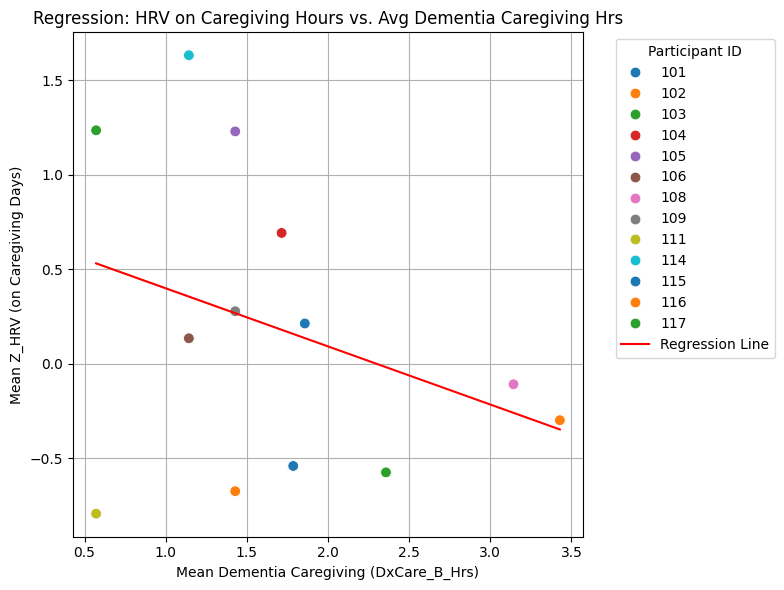

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Step 1: Filter relevant caregiving days and take absolute Z_HRV
df_care_hrs = df[['ID', 'Day', 'DxCare', 'Z_HRV', 'DxCG_Hrs_B']].dropna().copy()
#f_care_hrs['Z_HRV'] = df_care_hrs['Z_HRV'].abs()
df_care_hrs = df_care_hrs[df_care_hrs['DxCare'] == 1].copy()

# Step 2: Group by participant and calculate means
df_care_summary_hrs = df_care_hrs.groupby('ID').agg({
    'DxCG_Hrs_B': 'mean',
    'Z_HRV': 'mean'
}).reset_index()

# Rename columns for clarity
df_care_summary_hrs = df_care_summary_hrs.rename(columns={
    'DxCG_Hrs_B': 'Mean_DxCare_B_onCareHours',
    'Z_HRV': 'Mean_Z_HRV_onCareHours'
})

# Step 3: Define X and y for regression
X = df_care_summary_hrs[['Mean_DxCare_B_onCareHours']]
y = df_care_summary_hrs['Mean_Z_HRV_onCareHours']

# Step 4: Fit linear regression
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Step 5: Print evaluation metrics
print(f"R-squared: {r2_score(y, y_pred):.3f}")
print(f"Intercept: {model.intercept_:.3f}")
print(f"Coefficient: {model.coef_[0]:.3f}")

# Step 6: Plot with color-coded participants
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_care_summary_hrs,
    x='Mean_DxCare_B_onCareHours',
    y='Mean_Z_HRV_onCareHours',
    hue='ID',                  # Color-coded by participant
    palette='tab10',
    s=60
)

# Regression line (not participant-specific)
sns.lineplot(
    x=df_care_summary_hrs['Mean_DxCare_B_onCareHours'],
    y=y_pred,
    color='red',
    label='Regression Line'
)

plt.title('Regression: HRV on Caregiving Hours vs. Avg Dementia Caregiving Hrs')
plt.xlabel('Mean Dementia Caregiving (DxCare_B_Hrs)')
plt.ylabel('Mean Z_HRV (on Caregiving Days)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Participant ID")
plt.tight_layout()
plt.show()


R-squared: 0.001
Intercept: 0.100
Coefficient: 0.025


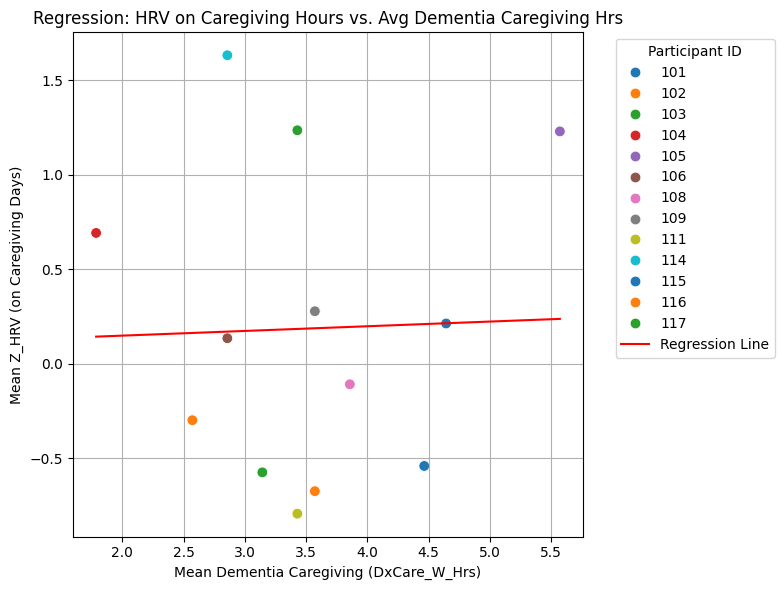

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Step 1: Filter relevant caregiving days and take absolute Z_HRV
df_care_hrs_within = df[['ID', 'Day', 'DxCare', 'Z_HRV', 'DxCG_Hrs_W']].dropna().copy()
#f_care_hrs['Z_HRV'] = df_care_hrs['Z_HRV'].abs()
df_care_hrs_within = df_care_hrs_within[df_care_hrs_within['DxCare'] == 1].copy()

# Step 2: Group by participant and calculate means
df_care_summary_hrs_within = df_care_hrs_within.groupby('ID').agg({
    'DxCG_Hrs_W': 'mean',
    'Z_HRV': 'mean'
}).reset_index()

# Rename columns for clarity
df_care_summary_hrs_within = df_care_summary_hrs_within.rename(columns={
    'DxCG_Hrs_W': 'Mean_DxCare_W_onCareHours',
    'Z_HRV': 'Mean_Z_HRV_onCareHours'
})

# Step 3: Define X and y for regression
X = df_care_summary_hrs_within[['Mean_DxCare_W_onCareHours']]
y = df_care_summary_hrs_within['Mean_Z_HRV_onCareHours']

# Step 4: Fit linear regression
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Step 5: Print evaluation metrics
print(f"R-squared: {r2_score(y, y_pred):.3f}")
print(f"Intercept: {model.intercept_:.3f}")
print(f"Coefficient: {model.coef_[0]:.3f}")

# Step 6: Plot with color-coded participants
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_care_summary_hrs_within,
    x='Mean_DxCare_W_onCareHours',
    y='Mean_Z_HRV_onCareHours',
    hue='ID',                  # Color-coded by participant
    palette='tab10',
    s=60
)

# Regression line (not participant-specific)
sns.lineplot(
    x=df_care_summary_hrs_within['Mean_DxCare_W_onCareHours'],
    y=y_pred,
    color='red',
    label='Regression Line'
)

plt.title('Regression: HRV on Caregiving Hours vs. Avg Dementia Caregiving Hrs')
plt.xlabel('Mean Dementia Caregiving (DxCare_W_Hrs)')
plt.ylabel('Mean Z_HRV (on Caregiving Days)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Participant ID")
plt.tight_layout()
plt.show()


R-squared: 0.171
Intercept: 0.568
Coefficient: 0.214


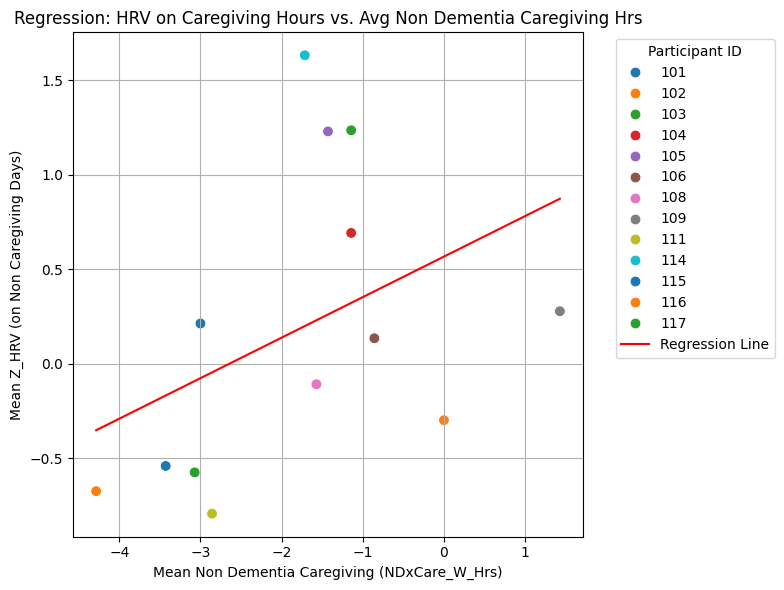

In [37]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Step 1: Filter relevant caregiving days and take absolute Z_HRV
df_Noncare_hrs_within = df[['ID', 'Day', 'DxCare', 'Z_HRV', 'NonDxCG_Hrs_W']].dropna().copy()
#f_care_hrs['Z_HRV'] = df_care_hrs['Z_HRV'].abs()
df_Noncare_hrs_within = df_Noncare_hrs_within[df_Noncare_hrs_within['DxCare'] == 1].copy()

# Step 2: Group by participant and calculate means
df_Noncare_summary_hrs_within = df_Noncare_hrs_within.groupby('ID').agg({
    'NonDxCG_Hrs_W': 'mean',
    'Z_HRV': 'mean'
}).reset_index()

# Rename columns for clarity
df_Noncare_summary_hrs_within = df_Noncare_summary_hrs_within.rename(columns={
    'NonDxCG_Hrs_W': 'Mean_DxCare_W_onNonCareHours',
    'Z_HRV': 'Mean_Z_HRV_onNonCareHours'
})

# Step 3: Define X and y for regression
X = df_Noncare_summary_hrs_within[['Mean_DxCare_W_onNonCareHours']]
y = df_Noncare_summary_hrs_within['Mean_Z_HRV_onNonCareHours']

# Step 4: Fit linear regression
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Step 5: Print evaluation metrics
print(f"R-squared: {r2_score(y, y_pred):.3f}")
print(f"Intercept: {model.intercept_:.3f}")
print(f"Coefficient: {model.coef_[0]:.3f}")

# Step 6: Plot with color-coded participants
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_Noncare_summary_hrs_within,
    x='Mean_DxCare_W_onNonCareHours',
    y='Mean_Z_HRV_onNonCareHours',
    hue='ID',                  # Color-coded by participant
    palette='tab10',
    s=60
)

# Regression line (not participant-specific)
sns.lineplot(
    x=df_Noncare_summary_hrs_within['Mean_DxCare_W_onNonCareHours'],
    y=y_pred,
    color='red',
    label='Regression Line'
)

plt.title('Regression: HRV on Caregiving Hours vs. Avg Non Dementia Caregiving Hrs')
plt.xlabel('Mean Non Dementia Caregiving (NDxCare_W_Hrs)')
plt.ylabel('Mean Z_HRV (on Non Caregiving Days)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Participant ID")
plt.tight_layout()
plt.show()


R-squared: 0.005
Intercept: -0.087
Coefficient: -0.033


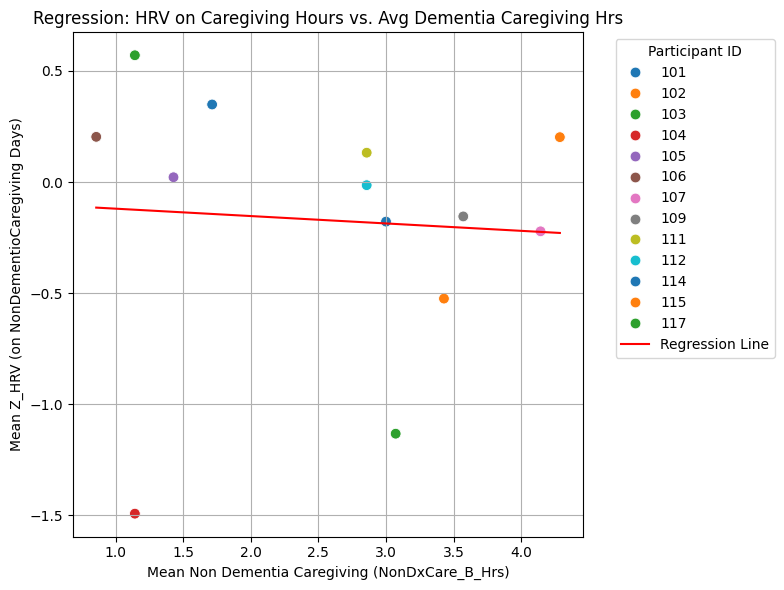

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Step 1: Filter relevant caregiving days and take absolute Z_HRV
df_NonDcare_hrs = df[['ID', 'Day', 'NDxCare', 'Z_HRV', 'NonDxCG_Hrs_B']].dropna().copy()
#f_care_hrs['Z_HRV'] = df_care_hrs['Z_HRV'].abs()
df_NonDcare_hrs = df_NonDcare_hrs[df_NonDcare_hrs['NDxCare'] == 1].copy()

# Step 2: Group by participant and calculate means
df_NonDcare_summary_hrs = df_NonDcare_hrs.groupby('ID').agg({
    'NonDxCG_Hrs_B': 'mean',
    'Z_HRV': 'mean'
}).reset_index()

# Rename columns for clarity
df_NonDcare_summary_hrs = df_NonDcare_summary_hrs.rename(columns={
    'NonDxCG_Hrs_B': 'Mean_NonDxCare_B_onDCareHours',
    'Z_HRV': 'Mean_Z_HRV_onNonDCareHours'
})

# Step 3: Define X and y for regression
X = df_NonDcare_summary_hrs[['Mean_NonDxCare_B_onDCareHours']]
y = df_NonDcare_summary_hrs['Mean_Z_HRV_onNonDCareHours']

# Step 4: Fit linear regression
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Step 5: Print evaluation metrics
print(f"R-squared: {r2_score(y, y_pred):.3f}")
print(f"Intercept: {model.intercept_:.3f}")
print(f"Coefficient: {model.coef_[0]:.3f}")

# Step 6: Plot with color-coded participants
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_NonDcare_summary_hrs,
    x='Mean_NonDxCare_B_onDCareHours',
    y='Mean_Z_HRV_onNonDCareHours',
    hue='ID',                  # Color-coded by participant
    palette='tab10',
    s=60
)

# Regression line (not participant-specific)
sns.lineplot(
    x=df_NonDcare_summary_hrs['Mean_NonDxCare_B_onDCareHours'],
    y=y_pred,
    color='red',
    label='Regression Line'
)

plt.title('Regression: HRV on Caregiving Hours vs. Avg Dementia Caregiving Hrs')
plt.xlabel('Mean Non Dementia Caregiving (NonDxCare_B_Hrs)')
plt.ylabel('Mean Z_HRV (on NonDementioCaregiving Days)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Participant ID")
plt.tight_layout()
plt.show()


In [39]:
df_care_summary_hrs

,ID,Mean_DxCare_B_onCareHours,Mean_Z_HRV_onCareHours
0,101,1.857143,0.213771
1,102,1.428571,-0.673427
2,103,0.571429,1.235868
3,104,1.714286,0.692902
4,105,1.428571,1.230042
5,106,1.142857,0.135613
6,108,3.142857,-0.107777
7,109,1.428571,0.278605
8,111,0.571429,-0.792317
9,114,1.142857,1.632940


R-squared: 0.316
Intercept: 0.788
Coefficient: -0.204


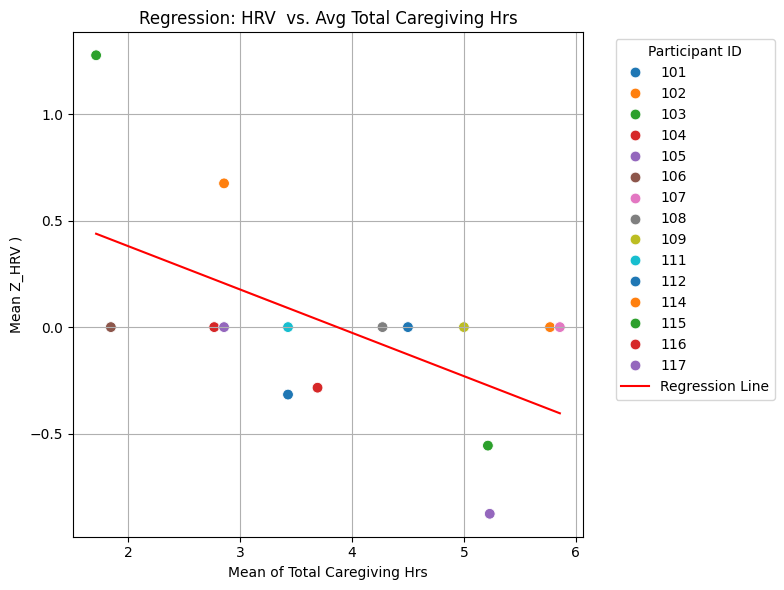

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Step 1: Filter relevant caregiving days and take absolute Z_HRV
df_Total_Caregiving_Hrs = df[['ID', 'Day', 'Caregiving_Hrs_Total', 'Z_HRV']].dropna().copy()



# Step 2: Group by participant and calculate means
df_Total_summary_hrs = df_Total_Caregiving_Hrs.groupby('ID').agg({
    'Caregiving_Hrs_Total': 'mean',
    'Z_HRV': 'mean'
}).reset_index()

# Rename columns for clarity
df_Total_summary_hrs = df_Total_summary_hrs.rename(columns={
    'Caregiving_Hrs_Total': 'Mean_Caregiving_Hrs',
    'Z_HRV': 'Mean_Z_HRV_Caregiving_Hrs'
})

# Step 3: Define X and y for regression
X = df_Total_summary_hrs[['Mean_Caregiving_Hrs']]
y = df_Total_summary_hrs['Mean_Z_HRV_Caregiving_Hrs']

# Step 4: Fit linear regression
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Step 5: Print evaluation metrics
print(f"R-squared: {r2_score(y, y_pred):.3f}")
print(f"Intercept: {model.intercept_:.3f}")
print(f"Coefficient: {model.coef_[0]:.3f}")

# Step 6: Plot with color-coded participants
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_Total_summary_hrs,
    x='Mean_Caregiving_Hrs',
    y='Mean_Z_HRV_Caregiving_Hrs',
    hue='ID',                  # Color-coded by participant
    palette='tab10',
    s=60
)

# Regression line (not participant-specific)
sns.lineplot(
    x=df_Total_summary_hrs['Mean_Caregiving_Hrs'],
    y=y_pred,
    color='red',
    label='Regression Line'
)

plt.title('Regression: HRV  vs. Avg Total Caregiving Hrs')
plt.xlabel('Mean of Total Caregiving Hrs')
plt.ylabel('Mean Z_HRV )')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Participant ID")
plt.tight_layout()
plt.show()


In [41]:
import pandas as pd
import statsmodels.formula.api as smf



# Convert participant ID to categorical if needed
df['ID'] = df['ID'].astype(str)

# Drop rows with missing relevant values
df_model_multilevel = df[['ID', 'Z_HRV', 'NonDxCG_Hrs_W', 'NonDxCG_Hrs_B']].dropna()

# Convert to numeric (in case some columns are string type)
df_model_multilevel['Z_HRV'] = pd.to_numeric(df_model_multilevel['Z_HRV'], errors='coerce')
df_model_multilevel['NonDxCG_Hrs_W'] = pd.to_numeric(df_model_multilevel['NonDxCG_Hrs_W'], errors='coerce')
df_model_multilevel['NonDxCG_Hrs_B'] = pd.to_numeric(df_model_multilevel['NonDxCG_Hrs_B'], errors='coerce')

# Drop any rows that still contain NaNs
df_model_multilevel = df_model_multilevel.dropna()

# Run multilevel model: Z_HRV ~ NonDxCG_Hrs_W + NonDxCG_Hrs_B with random intercepts for ID
model = smf.mixedlm("Z_HRV ~ NonDxCG_Hrs_B", df_model_multilevel, groups=df_model_multilevel["ID"])
result = model.fit()

# Print summary
print(result.summary())


         Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: Z_HRV    
No. Observations:  198     Method:             REML     
No. Groups:        15      Scale:              0.7425   
Min. group size:   10      Log-Likelihood:     -263.7999
Max. group size:   14      Converged:          Yes      
Mean group size:   13.2                                 
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      0.267    0.267  1.001 0.317 -0.256  0.789
NonDxCG_Hrs_B -0.116    0.100 -1.154 0.249 -0.313  0.081
Group Var      0.182    0.111                           



In [42]:
import pandas as pd
import statsmodels.formula.api as smf



# Convert participant ID to categorical if needed
df['ID'] = df['ID'].astype(str)

# Drop rows with missing relevant values
df_model_multilevel_1 = df[['ID', 'Z_HRV', 'DxCG_Hrs_W', 'DxCG_Hrs_B','Age', 'Total_Client']].dropna()

# Convert to numeric (in case some columns are string type)
df_model_multilevel_1['Z_HRV'] = pd.to_numeric(df_model_multilevel_1['Z_HRV'], errors='coerce')
df_model_multilevel_1['DxCG_Hrs_W'] = pd.to_numeric(df_model_multilevel_1['DxCG_Hrs_W'], errors='coerce')
df_model_multilevel_1['DxCG_Hrs_B'] = pd.to_numeric(df_model_multilevel_1['DxCG_Hrs_B'], errors='coerce')

# Drop any rows that still contain NaNs
df_model_multilevel_1 = df_model_multilevel_1.dropna()

# Run multilevel model: Z_HRV ~ NonDxCG_Hrs_W + NonDxCG_Hrs_B with random intercepts for ID
model_Multi_between = smf.mixedlm("Z_HRV ~  DxCG_Hrs_B + DxCG_Hrs_W + Total_Client + Age", df_model_multilevel_1, groups=df_model_multilevel_1["ID"])
result_beween = model_Multi_between.fit()


# Run multilevel model: Z_HRV ~ NonDxCG_Hrs_W + NonDxCG_Hrs_B with random intercepts for ID
model_Age_between = smf.mixedlm("Z_HRV ~  DxCG_Hrs_B + Age", df_model_multilevel_1, groups=df_model_multilevel_1["ID"])
result_age = model_Age_between.fit()

print(result_beween.summary())
# Print summary
print(result_age.summary())


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Z_HRV    
No. Observations: 198     Method:             REML     
No. Groups:       15      Scale:              0.7383   
Min. group size:  10      Log-Likelihood:     -267.3873
Max. group size:  14      Converged:          Yes      
Mean group size:  13.2                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    -0.988    1.196 -0.826 0.409 -3.332  1.356
DxCG_Hrs_B   -0.197    0.146 -1.351 0.177 -0.483  0.089
DxCG_Hrs_W    0.039    0.027  1.436 0.151 -0.014  0.092
Total_Client -0.080    0.073 -1.097 0.273 -0.223  0.063
Age           0.026    0.017  1.509 0.131 -0.008  0.059
Group Var     0.133    0.095                           

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Z_HRV    
No. Obser

In [44]:
import pandas as pd
import statsmodels.formula.api as smf



# Convert participant ID to categorical if needed
df['ID'] = df['ID'].astype(str)

# Drop rows with missing relevant values
df_model_multilevel_2 = df[['ID', 'Z_HRV', 'DxCare_W', 'DxCare_B','Age', 'Total_Client']].dropna()



# Convert to numeric (in case some columns are string type)
df_model_multilevel_2['Z_HRV'] = pd.to_numeric(df_model_multilevel_2['Z_HRV'], errors='coerce')
df_model_multilevel_2['DxCare_B'] = pd.to_numeric(df_model_multilevel_2['DxCare_B'], errors='coerce')
df_model_multilevel_2['DxCare_W'] = pd.to_numeric(df_model_multilevel_2['DxCare_W'], errors='coerce')

# Drop any rows that still contain NaNs
df_model_multilevel_2 = df_model_multilevel_2.dropna()

# Run multilevel model: Z_HRV ~ NonDxCG_Hrs_W + NonDxCG_Hrs_B with random intercepts for ID
model_2 = smf.mixedlm("Z_HRV ~ DxCare_W + DxCare_B + Age + Total_Client", df_model_multilevel_2, groups=df_model_multilevel_2["ID"])
result_1 = model_2.fit()



# Print summary
print(result_1.summary())



         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Z_HRV    
No. Observations: 198     Method:             REML     
No. Groups:       15      Scale:              0.7367   
Min. group size:  10      Log-Likelihood:     -263.8473
Max. group size:  14      Converged:          Yes      
Mean group size:  13.2                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    -1.087    1.279 -0.850 0.395 -3.594  1.420
DxCare_W      0.248    0.159  1.564 0.118 -0.063  0.559
DxCare_B     -1.033    1.020 -1.013 0.311 -3.033  0.966
Age           0.029    0.017  1.663 0.096 -0.005  0.063
Total_Client -0.127    0.091 -1.399 0.162 -0.305  0.051
Group Var     0.145    0.102                           



In [45]:
import pandas as pd
import statsmodels.formula.api as smf



# Convert participant ID to categorical if needed
df['ID'] = df['ID'].astype(str)

# Drop rows with missing relevant values
df_model_multilevel_Total = df[['ID', 'Z_HRV', 'Dx_Caregiving_Hrs_Total','Age', 'Total_Client']].dropna()

# Convert to numeric (in case some columns are string type)
df_model_multilevel_Total['Z_HRV'] = pd.to_numeric(df_model_multilevel_Total['Z_HRV'], errors='coerce')
df_model_multilevel_Total['Dx_Caregiving_Hrs_Total'] = pd.to_numeric(df_model_multilevel_Total['Dx_Caregiving_Hrs_Total'], errors='coerce')

df_model_multilevel_Total = df_model_multilevel_Total.dropna()

# Run multilevel model: Z_HRV ~ NonDxCG_Hrs_W + NonDxCG_Hrs_B with random intercepts for ID
model_Total = smf.mixedlm("Z_HRV ~ Dx_Caregiving_Hrs_Total + Age", df_model_multilevel_Total, groups=df_model_multilevel_Total["ID"])
result_total_age = model_Total.fit()



model_Total_Client= smf.mixedlm("Z_HRV ~ Dx_Caregiving_Hrs_Total + Total_Client", df_model_multilevel_Total, groups=df_model_multilevel_Total["ID"])

result_Total_Client = model_Total_Client.fit()

print(result_Total_Client.summary())

# Print summary
print(result_total_age.summary())





              Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    Z_HRV    
No. Observations:      198        Method:                REML     
No. Groups:            15         Scale:                 0.7386   
Min. group size:       10         Log-Likelihood:        -266.3562
Max. group size:       14         Converged:             Yes      
Mean group size:       13.2                                       
------------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept                0.219    0.345  0.634 0.526 -0.457  0.895
Dx_Caregiving_Hrs_Total  0.029    0.027  1.091 0.275 -0.023  0.082
Total_Client            -0.074    0.086 -0.856 0.392 -0.242  0.095
Group Var                0.206    0.124                           

              Mixed Linear Model Regression Results
Model:                 M

In [46]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import f

# ---------- ANOVA-based ICC(1,1) with 95% CI (Shrout & Fleiss, 1979) ----------
def icc1_anova_ci(temp_df, id_col, val_col, alpha=0.05):
    d = temp_df[[id_col, val_col]].dropna().copy()
    g = d.groupby(id_col)[val_col]

    n = g.ngroups
    if n < 2:
        raise ValueError("Need at least 2 IDs to compute ICC.")
    N = len(d)
    dfB = n - 1
    dfW = N - n
    if dfW < 1:
        raise ValueError("Not enough within-person degrees of freedom.")

    ni = g.size().astype(float).values           # counts per ID
    yi_bar = g.mean().values                     # subject means
    y_bar = d[val_col].mean()                    # grand mean

    # ANOVA sums of squares
    SSB = float(np.sum(ni * (yi_bar - y_bar) ** 2))                 # between
    SSW = float(np.sum((d[val_col] - g.transform('mean')) ** 2))    # within

    MSB = SSB / dfB
    MSW = SSW / dfW
    kbar = N / n  # average cluster size (handles unbalanced designs)

    # ICC(1,1)
    icc = (MSB - MSW) / (MSB + (kbar - 1) * MSW)

    # F-based CI
    Fobs = MSB / MSW
    F_lo = f.ppf(alpha / 2, dfB, dfW)
    F_hi = f.ppf(1 - alpha / 2, dfB, dfW)
    F_lo = max(F_lo, 1e-12)
    F_hi = max(F_hi, 1e-12)

    lower = (Fobs / F_hi - 1) / (Fobs / F_hi + (kbar - 1))
    upper = (Fobs / F_lo - 1) / (Fobs / F_lo + (kbar - 1))

    # Clamp to [0, 1] for reporting
    lower = float(max(0.0, lower))
    upper = float(min(1.0, upper))

    return float(icc), lower, upper, dict(MSB=MSB, MSW=MSW, dfB=dfB, dfW=dfW, kbar=kbar)

# ---------- Your main computation ----------
# Ensure ID is string
df['ID'] = df['ID'].astype(str)

outcomes = ['Z_HRV']
rows = []

for var in outcomes:
    try:
        temp_df = df[['ID', var]].dropna()

        # Point estimate via null random-intercept mixed model (as you had)
        model = smf.mixedlm(f"{var} ~ 1", temp_df, groups=temp_df["ID"])
        result = model.fit()

        var_between = float(result.cov_re.iloc[0, 0])
        var_within  = float(result.scale)
        icc_point   = var_between / (var_between + var_within)

        # 95% CI via ANOVA/F (no bootstrap, no delta)
        icc_anova, lo, hi, aux = icc1_anova_ci(temp_df, id_col='ID', val_col=var, alpha=0.05)

        # "mean ± std"-style DISPLAY (symmetric) using half-width of the CI (for formatting only)
        half_width = (hi - lo) / 2.0
        center_for_display = icc_point  # use your mixedlm ICC as the center
        plus_minus_str = f"{center_for_display:.3f} ± {half_width:.3f}"

        rows.append({
            'Variable': var,
            'ICC (mixedlm)': round(icc_point, 3),
            'ICC 95% CI (ANOVA/F)': f"[{lo:.3f}, {hi:.3f}]",
            'ICC ± (from CI half-width)': plus_minus_str,
            'ICC (Between %)': round(icc_point * 100, 2),
            'Within-Person %': round((1 - icc_point) * 100, 2),
            'Between Var (mixedlm)': round(var_between, 6),
            'Within Var (mixedlm)': round(var_within, 6),
            'k̄ (ANOVA)': round(aux['kbar'], 3),
            'MSB (ANOVA)': round(aux['MSB'], 6),
            'MSW (ANOVA)': round(aux['MSW'], 6),
            'dfB': aux['dfB'],
            'dfW': aux['dfW'],
        })
    except Exception as e:
        rows.append({
            'Variable': var,
            'ICC (mixedlm)': f"Error: {e}",
            'ICC 95% CI (ANOVA/F)': 'Error',
            'ICC ± (from CI half-width)': 'Error',
            'ICC (Between %)': 'Error',
            'Within-Person %': 'Error',
            'Between Var (mixedlm)': 'Error',
            'Within Var (mixedlm)': 'Error',
            'k̄ (ANOVA)': 'Error',
            'MSB (ANOVA)': 'Error',
            'MSW (ANOVA)': 'Error',
            'dfB': 'Error',
            'dfW': 'Error',
        })

icc_df = pd.DataFrame(rows)
print(icc_df)


  Variable  ICC (mixedlm) ICC 95% CI (ANOVA/F) ICC ± (from CI half-width)  \
0    Z_HRV          0.202       [0.089, 0.436]              0.202 ± 0.174   

   ICC (Between %)  Within-Person %  Between Var (mixedlm)  \
0            20.18            79.82               0.187732   

   Within Var (mixedlm)  k̄ (ANOVA)  MSB (ANOVA)  MSW (ANOVA)  dfB  dfW  
0              0.742368        13.2      3.28824     0.742976   14  183  


In [47]:
import pandas as pd
import statsmodels.formula.api as smf

df['ID'] = df['ID'].astype(str)

# Drop rows with missing values for relevant columns
model_df_mutltilevel = df[['ID', 'Z_HRV', 'DxCare_W', 'DxCare_B','DxCG_Hrs_B', 'DxCG_Hrs_W','Age','Total_Client']].dropna()

# Fit the multilevel model
model = smf.mixedlm(
    "Z_HRV ~ DxCare_W + DxCare_B + DxCG_Hrs_W + DxCG_Hrs_B + Age + Total_Client ",
    model_df_mutltilevel,
    groups=model_df_mutltilevel["ID"]
)
result = model.fit()

# Show results
print(result.summary())


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Z_HRV    
No. Observations: 198     Method:             REML     
No. Groups:       15      Scale:              0.7406   
Min. group size:  10      Log-Likelihood:     -266.1483
Max. group size:  14      Converged:          Yes      
Mean group size:  13.2                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    -0.971    1.302 -0.746 0.456 -3.523  1.581
DxCare_W      0.200    0.279  0.716 0.474 -0.347  0.746
DxCare_B     -0.050    1.557 -0.032 0.974 -3.101  3.001
DxCG_Hrs_W    0.011    0.047  0.230 0.818 -0.082  0.104
DxCG_Hrs_B   -0.194    0.230 -0.843 0.399 -0.644  0.257
Age           0.026    0.018  1.441 0.150 -0.009  0.061
Total_Client -0.083    0.106 -0.782 0.434 -0.290  0.125
Group Var     0.150    0.109                           



In [48]:
import pandas as pd
import statsmodels.formula.api as smf

# Load your cleaned dataframe
df['ID'] = df['ID'].astype(str)

# Drop rows with missing values
df_model_Interaction = df[['ID', 'Z_HRV','NDxCare_W','NDxCare_B','NonDxCG_Hrs_W','NonDxCG_Hrs_B', 'Age', 'Total_Client']].dropna()

# Optional: center age for interpretation
#df_model_Interaction['Age_c'] = df_model_Interaction['Age'] - df_model_Interaction['Age01'].mean()

# Add interaction term: DxCare_B * Age
#df_model_Interaction['DxCareB_x_Age'] = df_model_Interaction['DxCare_B'] * df_model_Interaction['Age_c']

# Fit the model
model_Interaction = smf.mixedlm("Z_HRV ~ NDxCare_W + NDxCare_B + NonDxCG_Hrs_W + NonDxCG_Hrs_B + Age + Total_Client",
                    df_model_Interaction, groups=df_model_Interaction["ID"])


result = model_Interaction.fit()

print(result.summary())

         Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: Z_HRV    
No. Observations:  198     Method:             REML     
No. Groups:        15      Scale:              0.7447   
Min. group size:   10      Log-Likelihood:     -267.2759
Max. group size:   14      Converged:          Yes      
Mean group size:   13.2                                 
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept     -1.956    1.055 -1.854 0.064 -4.024  0.112
NDxCare_W     -0.316    0.275 -1.149 0.250 -0.856  0.223
NDxCare_B      1.073    0.858  1.250 0.211 -0.609  2.755
NonDxCG_Hrs_W  0.030    0.039  0.758 0.449 -0.047  0.107
NonDxCG_Hrs_B -0.266    0.175 -1.519 0.129 -0.608  0.077
Age            0.033    0.016  2.022 0.043  0.001  0.066
Total_Client   0.058    0.119  0.485 0.628 -0.176  0.291
Group Var      0.137    0.102            

In [49]:
import pandas as pd
import statsmodels.formula.api as smf

# Load your cleaned dataframe
df['ID'] = df['ID'].astype(str)

# Drop rows with missing values
df_model_Interaction_1 = df[['ID', 'Z_HRV', 'DxCG_Hrs_B', 'DxCG_Hrs_W', 'Age', 'Total_Client']].dropna()

# Optional: center age for interpretation
#df_model_Interaction['Age_c'] = df_model_Interaction['Age'] - df_model_Interaction['Age01'].mean()

# Add interaction term: DxCare_B * Age
#df_model_Interaction['DxCareB_x_Age'] = df_model_Interaction['DxCare_B'] * df_model_Interaction['Age_c']

# Fit the model
model_Interaction_1 = smf.mixedlm("Z_HRV ~ DxCG_Hrs_W + DxCG_Hrs_B+Age+Total_Client",
                    df_model_Interaction_1, groups=df_model_Interaction_1["ID"])
result_i = model_Interaction_1.fit()

print(result_i.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Z_HRV    
No. Observations: 198     Method:             REML     
No. Groups:       15      Scale:              0.7383   
Min. group size:  10      Log-Likelihood:     -267.3873
Max. group size:  14      Converged:          Yes      
Mean group size:  13.2                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    -0.988    1.196 -0.826 0.409 -3.332  1.356
DxCG_Hrs_W    0.039    0.027  1.436 0.151 -0.014  0.092
DxCG_Hrs_B   -0.197    0.146 -1.351 0.177 -0.483  0.089
Age           0.026    0.017  1.509 0.131 -0.008  0.059
Total_Client -0.080    0.073 -1.097 0.273 -0.223  0.063
Group Var     0.133    0.095                           

